In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import warnings
import scanpy as sc

warnings.filterwarnings("ignore")

In [12]:
"""
Cluster-Metadata Association Analysis
======================================
Quantifies how strongly leiden clusters correlate with metadata fields
using NMI, ARI, per-cluster entropy, chi-square, and composition heatmaps.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import chi2_contingency, entropy
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
import warnings
warnings.filterwarnings('ignore')


# ── 1. Subsample ──────────────────────────────────────────────────────────────

def multilevel_stratified_subsample(adata, keys, n_per_group=200, random_state=42):
    """
    Sample up to n_per_group cells per unique combination of `keys`.
    Guarantees representation across all cluster × metadata combinations.
    """
    np.random.seed(random_state)
    obs = adata.obs.copy()
    obs['_combined'] = obs[keys].astype(str).agg('_'.join, axis=1)

    idx = []
    for group in obs['_combined'].unique():
        group_idx = np.where(obs['_combined'] == group)[0]
        n = min(n_per_group, len(group_idx))
        idx.extend(np.random.choice(group_idx, size=n, replace=False))

    adata_sub = adata[np.array(idx)].copy()
    print(f"Subsampled: {adata.n_obs:,} → {adata_sub.n_obs:,} cells")
    return adata_sub


# ── 2. NMI / ARI table ────────────────────────────────────────────────────────

def compute_association_table(adata, cluster_key='leiden', metadata_fields=None):
    """
    Compute NMI and ARI between leiden clusters and every metadata field.
    Returns a DataFrame sorted by NMI descending.
    """
    if metadata_fields is None:
        # Auto-detect categorical / low-cardinality columns, exclude cluster key
        metadata_fields = [
            col for col in adata.obs.columns
            if col != cluster_key
            and (adata.obs[col].dtype.name in ('category', 'object')
                 or adata.obs[col].nunique() < 50)
        ]

    results = {}
    for field in metadata_fields:
        mask = adata.obs[field].notna()
        if mask.sum() == 0:
            continue
        leiden = adata.obs.loc[mask, cluster_key].astype(str)
        meta   = adata.obs.loc[mask, field].astype(str)

        results[field] = {
            'NMI': normalized_mutual_info_score(leiden, meta),
            'ARI': adjusted_rand_score(leiden, meta),
        }

    df = pd.DataFrame(results).T.sort_values('NMI', ascending=False)
    return df


# ── 3. Chi-square p-values ────────────────────────────────────────────────────

def compute_chi2(adata, cluster_key='leiden', metadata_fields=None):
    """
    Chi-square test of independence between leiden clusters and each metadata field.
    """
    if metadata_fields is None:
        metadata_fields = [
            col for col in adata.obs.columns
            if col != cluster_key
            and (adata.obs[col].dtype.name in ('category', 'object')
                 or adata.obs[col].nunique() < 50)
        ]

    rows = []
    for field in metadata_fields:
        mask = adata.obs[field].notna()
        ct = pd.crosstab(
            adata.obs.loc[mask, cluster_key],
            adata.obs.loc[mask, field]
        )
        chi2, p, dof, _ = chi2_contingency(ct)
        rows.append({'field': field, 'chi2': chi2, 'p_value': p, 'dof': dof})

    return pd.DataFrame(rows).set_index('field').sort_values('p_value')


# ── 4. Per-cluster entropy ────────────────────────────────────────────────────

def cluster_entropy(adata, cluster_key='leiden', meta_key='batch'):
    """
    Shannon entropy of `meta_key` within each cluster.
    Low entropy = cluster dominated by one category (potential technical effect).
    """
    results = {}
    for cluster in adata.obs[cluster_key].unique():
        mask = adata.obs[cluster_key] == cluster
        counts = adata.obs.loc[mask, meta_key].value_counts(normalize=True)
        results[cluster] = entropy(counts, base=2)
    return pd.Series(results).sort_values()


# ── 5. Plotting ───────────────────────────────────────────────────────────────

def plot_association_summary(assoc_df, title='Cluster–Metadata Association'):
    """
    Horizontal bar chart of NMI and ARI for all metadata fields.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(assoc_df) * 0.5)))
    palette = {'NMI': '#2D7DD2', 'ARI': '#E84855'}

    for ax, metric in zip(axes, ['NMI', 'ARI']):
        vals = assoc_df[metric].sort_values(ascending=True)
        colors = [palette[metric]] * len(vals)
        ax.barh(vals.index, vals.values, color=colors, edgecolor='white', linewidth=0.5)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel(metric, fontsize=12)
        ax.set_title(f'{metric} vs. Leiden Clusters', fontsize=13, fontweight='bold')
        ax.spines[['top', 'right']].set_visible(False)
        for i, v in enumerate(vals.values):
            ax.text(max(v + 0.002, 0.002), i, f'{v:.3f}', va='center', fontsize=9)

    fig.suptitle(title, fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    return fig


def plot_composition_heatmap(adata, cluster_key='leiden', meta_key='batch',
                              normalize='index'):
    """
    Heatmap of cluster composition by a metadata field.
    normalize='index'  → fraction of each cluster (rows sum to 1)
    normalize='columns'→ fraction of each metadata category
    """
    ct = pd.crosstab(
        adata.obs[cluster_key],
        adata.obs[meta_key],
        normalize=normalize
    )
    fig, ax = plt.subplots(figsize=(max(8, ct.shape[1] * 0.6),
                                    max(5, ct.shape[0] * 0.35)))
    sns.heatmap(ct, cmap='YlOrRd', ax=ax, linewidths=0.3,
                linecolor='white', cbar_kws={'label': 'Fraction'})
    ax.set_title(f'Cluster Composition by {meta_key}', fontsize=13, fontweight='bold')
    ax.set_xlabel(meta_key, fontsize=11)
    ax.set_ylabel('Leiden Cluster', fontsize=11)
    plt.tight_layout()
    return fig


def plot_entropy_per_cluster(adata, cluster_key='leiden', meta_key='batch'):
    """
    Bar chart of per-cluster entropy for a given metadata field.
    Low entropy clusters are highlighted in red.
    """
    ent = cluster_entropy(adata, cluster_key, meta_key)
    threshold = ent.quantile(0.25)  # bottom quartile = most dominated

    colors = ['#E84855' if v <= threshold else '#2D7DD2' for v in ent.values]
    fig, ax = plt.subplots(figsize=(max(8, len(ent) * 0.5), 4))
    ax.bar(ent.index.astype(str), ent.values, color=colors, edgecolor='white')
    ax.axhline(threshold, color='grey', linestyle='--', linewidth=1,
               label=f'25th percentile ({threshold:.2f})')
    ax.set_xlabel('Leiden Cluster', fontsize=11)
    ax.set_ylabel('Entropy (bits)', fontsize=11)
    ax.set_title(f'Per-Cluster Entropy of {meta_key}\n(red = lowest mixing)',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    return fig


# ── 6. Full pipeline ──────────────────────────────────────────────────────────

def run_cluster_metadata_analysis(
    adata,
    cluster_key='leiden',
    metadata_fields=None,
    subsample=True,
    subsample_keys=None,
    n_per_group=200,
    heatmap_fields=None,   # which fields to plot composition heatmaps for
    entropy_field='batch', # which field to use for per-cluster entropy
    save_prefix=None,      # e.g. 'results/my_analysis' → saves PNGs
):
    """
    Full pipeline:
      1. (Optional) stratified subsample
      2. NMI / ARI table
      3. Chi-square table
      4. Per-cluster entropy
      5. Summary plots
    
    Returns
    -------
    dict with keys: 'assoc_table', 'chi2_table', 'entropy', 'adata_sub'
    """
    # ── Subsample
    if subsample:
        keys = subsample_keys or ([cluster_key] + (metadata_fields or [])[:1])
        adata_sub = multilevel_stratified_subsample(adata, keys=keys,
                                                    n_per_group=n_per_group)
    else:
        adata_sub = adata

    # ── Association table
    print("\n── NMI / ARI Table ──")
    assoc_df = compute_association_table(adata_sub, cluster_key, metadata_fields)
    print(assoc_df.to_string())

    # ── Chi-square
    print("\n── Chi-Square Table ──")
    chi2_df = compute_chi2(adata_sub, cluster_key, metadata_fields)
    print(chi2_df.to_string())

    # ── Entropy
    print(f"\n── Per-Cluster Entropy ({entropy_field}) ──")
    ent = cluster_entropy(adata_sub, cluster_key, entropy_field)
    print(ent.to_string())

    # ── Plots
    fig_assoc = plot_association_summary(assoc_df)
    fig_entropy = plot_entropy_per_cluster(adata_sub, cluster_key, entropy_field)

    heatmap_figs = {}
    for field in (heatmap_fields or [entropy_field]):
        heatmap_figs[field] = plot_composition_heatmap(adata_sub, cluster_key, field)

    if save_prefix:
        fig_assoc.savefig(f'{save_prefix}_association_summary.png', dpi=150, bbox_inches='tight')
        fig_entropy.savefig(f'{save_prefix}_entropy_{entropy_field}.png', dpi=150, bbox_inches='tight')
        for field, fig in heatmap_figs.items():
            fig.savefig(f'{save_prefix}_heatmap_{field}.png', dpi=150, bbox_inches='tight')
        assoc_df.to_csv(f'{save_prefix}_nmi_ari.csv')
        chi2_df.to_csv(f'{save_prefix}_chi2.csv')
        print(f"\nSaved outputs with prefix: {save_prefix}")

    return {
        'assoc_table':  assoc_df,
        'chi2_table':   chi2_df,
        'entropy':      ent,
        'adata_sub':    adata_sub,
        'figures': {
            'association': fig_assoc,
            'entropy':     fig_entropy,
            'heatmaps':    heatmap_figs,
        }
    }

'''
# ── Example usage ─────────────────────────────────────────────────────────────

if __name__ == '__main__':
    # import scanpy as sc
    # adata = sc.read_h5ad('your_data.h5ad')

    metadata_fields = [
        'sample_id', 'bri_id', 'batch_id', 'slide_id',
        'donor', 'anatomical_site', 'batch', 'slide_roi',
        'disease', 'clinical_response', 'vdz_status'
    ]

    results = run_cluster_metadata_analysis(
        adata,
        cluster_key='leiden',
        metadata_fields=metadata_fields,
        subsample=True,
        subsample_keys=['leiden', 'batch_id'],  # stratify on cluster + batch
        n_per_group=300,
        heatmap_fields=['batch_id', 'disease', 'sample_id'],
        entropy_field='batch_id',
        save_prefix='results/cluster_metadata',
    )

    # Access individual outputs
    assoc_table = results['assoc_table']
    chi2_table  = results['chi2_table']
    entropy     = results['entropy']
    plt.show()

'''

"\n# ── Example usage ─────────────────────────────────────────────────────────────\n\nif __name__ == '__main__':\n    # import scanpy as sc\n    # adata = sc.read_h5ad('your_data.h5ad')\n\n    metadata_fields = [\n        'sample_id', 'bri_id', 'batch_id', 'slide_id',\n        'donor', 'anatomical_site', 'batch', 'slide_roi',\n        'disease', 'clinical_response', 'vdz_status'\n    ]\n\n    results = run_cluster_metadata_analysis(\n        adata,\n        cluster_key='leiden',\n        metadata_fields=metadata_fields,\n        subsample=True,\n        subsample_keys=['leiden', 'batch_id'],  # stratify on cluster + batch\n        n_per_group=300,\n        heatmap_fields=['batch_id', 'disease', 'sample_id'],\n        entropy_field='batch_id',\n        save_prefix='results/cluster_metadata',\n    )\n\n    # Access individual outputs\n    assoc_table = results['assoc_table']\n    chi2_table  = results['chi2_table']\n    entropy     = results['entropy']\n    plt.show()\n\n"

In [25]:
"""
Sample Coverage Analysis — Jupyter Notebook
============================================
Copy each block into its own cell and run top to bottom.
Requires: scanpy, pandas, numpy, matplotlib, seaborn
"""

# ── Cell 1: Imports ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120


# ── Cell 2: Build coverage matrices ──────────────────────────────────────────
def build_coverage_matrices(adata, cluster_key='leiden', sample_key='sample_id',
                             min_cells=5, min_frac=0.01):
    """
    Returns a dict of DataFrames (all indexed clusters × samples):

      count          — raw cell counts
      frac_of_sample — fraction of each sample's cells landing in each cluster
                       (columns sum to 1). Use this to spot samples with poor
                       representation in a cluster.
      frac_of_cluster— fraction of each cluster made up by each sample
                       (rows sum to 1). Same as a composition heatmap.
      presence       — boolean: True if BOTH thresholds are met.
    """
    count = pd.crosstab(
        adata.obs[cluster_key].astype(str),
        adata.obs[sample_key].astype(str),
    )

    # Sort clusters numerically where possible
    try:
        count = count.loc[sorted(count.index, key=lambda x: int(x))]
    except (ValueError, TypeError):
        count = count.sort_index()

    frac_of_sample  = count.div(count.sum(axis=0), axis=1)   # column-normalize
    frac_of_cluster = count.div(count.sum(axis=1), axis=0)   # row-normalize
    presence        = (count >= min_cells) & (frac_of_sample >= min_frac)

    return {
        'count':           count,
        'frac_of_sample':  frac_of_sample,
        'frac_of_cluster': frac_of_cluster,
        'presence':        presence,
    }


# ── Cell 3: Summary statistics ────────────────────────────────────────────────
def summarise_coverage(matrices, min_cells=5, min_frac=0.01):
    """
    Prints per-sample and per-cluster coverage tables, plus an explicit
    list of every (cluster, sample) pair that fails the thresholds.
    """
    presence   = matrices['presence']
    n_clusters = presence.shape[0]
    n_samples  = presence.shape[1]

    print("Cluster dtype:", adata.obs['leiden'].dtype)
    print("Sample dtype:", adata.obs['sample_id'].dtype)
    print("Unique clusters:", adata.obs['leiden'].unique()[:10])
    print("Count matrix index:", matrices['count'].index.tolist()[:10])
    print("Count matrix dtypes:", matrices['count'].index.dtype)

    per_sample = pd.DataFrame({
        'clusters_present_in':   presence.sum(axis=0),
        'clusters_missing_from': (~presence).sum(axis=0),
        'pct_coverage':          presence.sum(axis=0) / n_clusters * 100,
        'total_cells':           matrices['count'].sum(axis=0),
    }).sort_values('pct_coverage')

    per_cluster = pd.DataFrame({
        'samples_present': presence.sum(axis=1),
        'samples_missing': (~presence).sum(axis=1),
        'pct_coverage':    presence.sum(axis=1) / n_samples * 100,
        'total_cells':     matrices['count'].sum(axis=1),
    }).sort_values('pct_coverage')

    missing_rows = [
        {
            'cluster':         cluster,
            'sample':          sample,
            'n_cells':         matrices['count'].loc[cluster, sample],
            'frac_of_sample':  matrices['frac_of_sample'].loc[cluster, sample],
            'status':          'ABSENT' if matrices['count'].loc[cluster, sample] == 0 else 'SPARSE',
        }
        for cluster in presence.index
        for sample  in presence.columns
        if not presence.loc[cluster, sample]
    ]
    missing_df = (pd.DataFrame(missing_rows) if missing_rows
                  else pd.DataFrame(columns=['cluster','sample','n_cells','frac_of_sample','status']))

    print(f"Thresholds — min_cells: {min_cells}  |  min_frac: {min_frac:.1%}")
    print(f"Total pairs: {n_clusters * n_samples}  |  "
          f"Present: {int(presence.sum().sum())}  |  "
          f"Missing: {len(missing_df)}\n")

    print("── Per-Sample Coverage ──────────────────────────────────────────")
    print(per_sample.to_string(), "\n")

    print("── Per-Cluster Coverage ─────────────────────────────────────────")
    print(per_cluster.to_string(), "\n")

    print(f"── Missing Pairs ({len(missing_df)}) ──────────────────────────────────────")

    if missing_df.empty:
        print("✓ All samples represented in all clusters.")
    else:
        print(missing_df.sort_values(['cluster','sample']).to_string(index=False))

    return {'per_sample': per_sample, 'per_cluster': per_cluster, 'missing': missing_df}


# ── Cell 4: Presence heatmap ──────────────────────────────────────────────────
def plot_presence_heatmap(matrices, cluster_key='leiden', sample_key='sample_id',
                          figsize=None, save_path=None):
    """
    Main coverage heatmap.

    Blue intensity  — fraction of that sample's total cells in the cluster.
                      A well-distributed sample should show even blue across all rows.
    ✕ (red)         — this (cluster, sample) pair is BELOW threshold.
    Small number    — raw cell count in each cell.
    """
    presence = matrices['presence']
    frac     = matrices['frac_of_sample']
    counts   = matrices['count']
    n_c, n_s = presence.shape

    fw = max(12, n_s * 0.65)
    fh = max(6,  n_c * 0.42)
    fig, ax = plt.subplots(figsize=figsize or (fw, fh))

    # Base: frac_of_sample as blue heatmap
    sns.heatmap(
        frac, ax=ax, cmap='Blues', vmin=0,
        annot=False, linewidths=0.4, linecolor='#e0e0e0',
        cbar_kws={'label': "Fraction of sample's total cells", 'shrink': 0.55},
    )

    # Overlay ✕ where absent/sparse
    for i, cluster in enumerate(presence.index):
        for j, sample in enumerate(presence.columns):
            if not presence.loc[cluster, sample]:
                ax.text(j + 0.5, i + 0.5, '✕',
                        ha='center', va='center',
                        fontsize=10, color='#E84855', fontweight='bold', zorder=5)

    # Raw count annotation (small, bottom of cell)
    for i, cluster in enumerate(counts.index):
        for j, sample in enumerate(counts.columns):
            ax.text(j + 0.5, i + 0.75, str(counts.loc[cluster, sample]),
                    ha='center', va='center',
                    fontsize=6, color='#333', alpha=0.65, zorder=4)

    ax.set_title(
        f'Sample Coverage per Cluster\n'
        f'Blue = fraction of {sample_key} cells  ·  ✕ = below threshold  ·  small number = cell count',
        fontsize=13, fontweight='bold', pad=14,
    )
    ax.set_xlabel(sample_key, fontsize=12, labelpad=8)
    ax.set_ylabel(f'{cluster_key} Cluster', fontsize=12, labelpad=8)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', rotation=0,  labelsize=9)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved → {save_path}")
    plt.show()
    return fig


# ── Cell 5: Coverage bar charts ───────────────────────────────────────────────
def plot_coverage_bars(summary, sample_key='sample_id', figsize=(14, 5),
                       pct_threshold=75, save_path=None):
    """
    Left  — % of clusters each sample is present in  (worst → best).
    Right — % of samples present in each cluster      (worst → best).
    Red bars fall below `pct_threshold`.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    def _bar(ax, df, pct_col, total_col, xlabel, title):
        df = df.sort_values(pct_col)
        colors = ['#E84855' if v < pct_threshold else '#4A9EBF' for v in df[pct_col]]
        ax.barh(df.index.astype(str), df[pct_col], color=colors,
                edgecolor='white', linewidth=0.5)
        ax.axvline(pct_threshold, color='#E84855', linestyle='--',
                   linewidth=1.3, label=f'{pct_threshold}% threshold')
        ax.axvline(100, color='#2ecc71', linestyle=':', linewidth=1.2,
                   label='Full coverage')
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlim(0, 115)
        ax.legend(fontsize=9, frameon=False)
        ax.spines[['top', 'right']].set_visible(False)
        for i, (v, n) in enumerate(zip(df[pct_col], df[total_col])):
            ax.text(v + 1, i, f'{v:.0f}%  (n={n:,})',
                    va='center', fontsize=8.5, color='#444')

    _bar(ax1, summary['per_sample'], 'pct_coverage', 'total_cells',
         '% of clusters represented in',
         f'Per-{sample_key}: Cluster Coverage\n(red = <{pct_threshold}%)')

    _bar(ax2, summary['per_cluster'], 'pct_coverage', 'total_cells',
         '% of samples present',
         f'Per-Cluster: Sample Coverage\n(red = <{pct_threshold}%)')

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved → {save_path}")
    plt.show()
    return fig


# ── Cell 6: Binary presence/absence heatmap ───────────────────────────────────
def plot_presence_absence(matrices, cluster_key='leiden', sample_key='sample_id',
                          figsize=None, save_path=None):
    """
    Clean binary view: green = present, red = absent.
    Best overview when you have many samples and want a fast QC read.
    """
    presence = matrices['presence']
    n_c, n_s = presence.shape
    fw = max(8, n_s * 0.55)
    fh = max(5, n_c * 0.38)

    fig, ax = plt.subplots(figsize=figsize or (fw, fh))
    sns.heatmap(
        presence.astype(int), ax=ax,
        cmap=['#E84855', '#2ecc71'], vmin=0, vmax=1,
        linewidths=0.5, linecolor='white', cbar=False,
    )

    legend_elements = [
        mpatches.Patch(facecolor='#2ecc71', label='Present  (meets threshold)'),
        mpatches.Patch(facecolor='#E84855', label='Absent / below threshold'),
    ]
    ax.legend(handles=legend_elements, loc='lower center',
              bbox_to_anchor=(0.5, -0.18), fontsize=10,
              frameon=False, ncol=2)

    ax.set_title('Sample Presence / Absence per Cluster',
                 fontsize=13, fontweight='bold', pad=14)
    ax.set_xlabel(sample_key, fontsize=12, labelpad=8)
    ax.set_ylabel(f'{cluster_key} Cluster', fontsize=12, labelpad=8)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', rotation=0,  labelsize=9)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved → {save_path}")
    plt.show()
    return fig

In [3]:
import pandas as pd

# Load metadata CSV
metadata = pd.read_csv("/home/workspace/private/reference_sheet_VDZ.csv")

# Set index to image_id for easy merging
metadata = metadata.set_index('image_id')

# Merge metadata into adata.obs using sample_id as the key
adata.obs = adata.obs.join(metadata, on='sample_id', how='left')

# Confirm
print(f"New adata.obs columns: {adata.obs.columns.tolist()}")

# Check for any sample_ids that didn't match
unmatched = adata.obs[adata.obs[metadata.columns[0]].isna()]['sample_id'].unique()
if len(unmatched) > 0:
    print(f"\n⚠️  Unmatched sample_ids (not found in CSV): {unmatched.tolist()}")
else:
    print(f"\n✓ All sample_ids matched successfully")

adata

New adata.obs columns: ['cell_id', 'sample_id', 'Timeframe', 'batch_id', 'x', 'y', 'Outline Area (µm²)', 'Perimeter (µm)', 'Circularity', 'leiden', 'slide_id', 'slide_roi', 'bri_id', 'donor', 'biopsy_code', 'anatomical_site', 'vdz_status', 'clinical_response', 'disease', 'batch']

✓ All sample_ids matched successfully


AnnData object with n_obs × n_vars = 4374290 × 52
    obs: 'cell_id', 'sample_id', 'Timeframe', 'batch_id', 'x', 'y', 'Outline Area (µm²)', 'Perimeter (µm)', 'Circularity', 'leiden', 'slide_id', 'slide_roi', 'bri_id', 'donor', 'biopsy_code', 'anatomical_site', 'vdz_status', 'clinical_response', 'disease', 'batch'
    var: 'marker_name'
    uns: 'leiden', 'neighbors', 'umap'
    obsm: 'X_umap'
    layers: 'X_mean', 'intensity_mean', 'intensity_median', 'intensity_std', 'normalized'
    obsp: 'connectivities', 'distances'

In [2]:
adata = sc.read_h5ad('/home/workspace/private/working/R05clustered_adata_031026.h5ad')
adata

AnnData object with n_obs × n_vars = 4374290 × 52
    obs: 'cell_id', 'sample_id', 'Timeframe', 'batch_id', 'x', 'y', 'Outline Area (µm²)', 'Perimeter (µm)', 'Circularity', 'leiden'
    var: 'marker_name'
    uns: 'leiden', 'neighbors', 'umap'
    obsm: 'X_umap'
    layers: 'X_mean', 'intensity_mean', 'intensity_median', 'intensity_std', 'normalized'
    obsp: 'connectivities', 'distances'

In [29]:
raw = pd.crosstab(
    adata.obs['leiden'].astype(str),
    adata.obs['sample_id'].astype(str)
)

n_donors = raw.shape[1]
donors_per_cluster = (raw > 0).sum(axis=1).sort_values()

# Your criterion: present in at least 4 donors
min_donors = 4
failing = donors_per_cluster[donors_per_cluster < min_donors]
passing = donors_per_cluster[donors_per_cluster >= min_donors]

print(f"Total clusters: {len(donors_per_cluster)}")
print(f"Total donors: {n_donors}")
print(f"\n✓ Clusters present in >={min_donors} donors: {len(passing)}")
print(f"✗ Clusters present in <{min_donors} donors: {len(failing)}")

if not failing.empty:
    print(f"\nProblematic clusters:")
    print(failing.to_string())
else:
    print("\n✓ All clusters pass the minimum donor threshold.")

Total clusters: 41
Total donors: 50

✓ Clusters present in >=4 donors: 38
✗ Clusters present in <4 donors: 3

Problematic clusters:
leiden
37    1
38    1
34    2


In [30]:
raw = pd.crosstab(
    adata.obs['leiden'].astype(str),
    adata.obs['sample_id'].astype(str)
)

# Clusters per sample
clusters_per_sample = (raw > 0).sum(axis=0).sort_values()

# Samples per cluster
samples_per_cluster = (raw > 0).sum(axis=1).sort_values()

print("── Clusters per sample ──────────────────────────────")
print(clusters_per_sample.to_string())
print(f"\nMean: {clusters_per_sample.mean():.1f}  |  Min: {clusters_per_sample.min()}  |  Max: {clusters_per_sample.max()}")

print("\n── Samples per cluster ──────────────────────────────")
print(samples_per_cluster.to_string())
print(f"\nMean: {samples_per_cluster.mean():.1f}  |  Min: {samples_per_cluster.min()}  |  Max: {samples_per_cluster.max()}")

── Clusters per sample ──────────────────────────────
sample_id
MS00000943_R1    14
MS00000925_R0    27
MS00000917_R1    28
MS00000921_R1    28
MS00000915_R0    29
MS00000961_R1    29
MS00000957_R0    29
MS00000953_R0    29
MS00000929_R0    29
MS00000939_R0    29
MS00000965_R1    29
MS00000927_R1    30
MS00000915_R1    30
MS00000933_R1    30
MS00000951_R0    30
MS00000935_R1    30
MS00000919_R1    31
MS00000943_R0    31
MS00000951_R1    31
MS00000965_R0    31
MS00000937_R1    31
MS00000937_R0    31
MS00000935_R0    31
MS00000961_R0    31
MS00000931_R0    31
MS00000921_R0    31
MS00000927_R0    31
MS00000925_R1    31
MS00000957_R1    31
MS00000949_R0    31
MS00000955_R1    32
MS00000923_R0    32
MS00000923_R1    32
MS00000947_R0    32
MS00000917_R0    33
MS00000963_R1    33
MS00000963_R0    33
MS00000953_R1    33
MS00000959_R0    33
MS00000931_R1    34
MS00000959_R1    34
MS00000945_R0    34
MS00000939_R1    34
MS00000941_R0    34
MS00000949_R1    34
MS00000945_R1    34
MS00000933_R0   

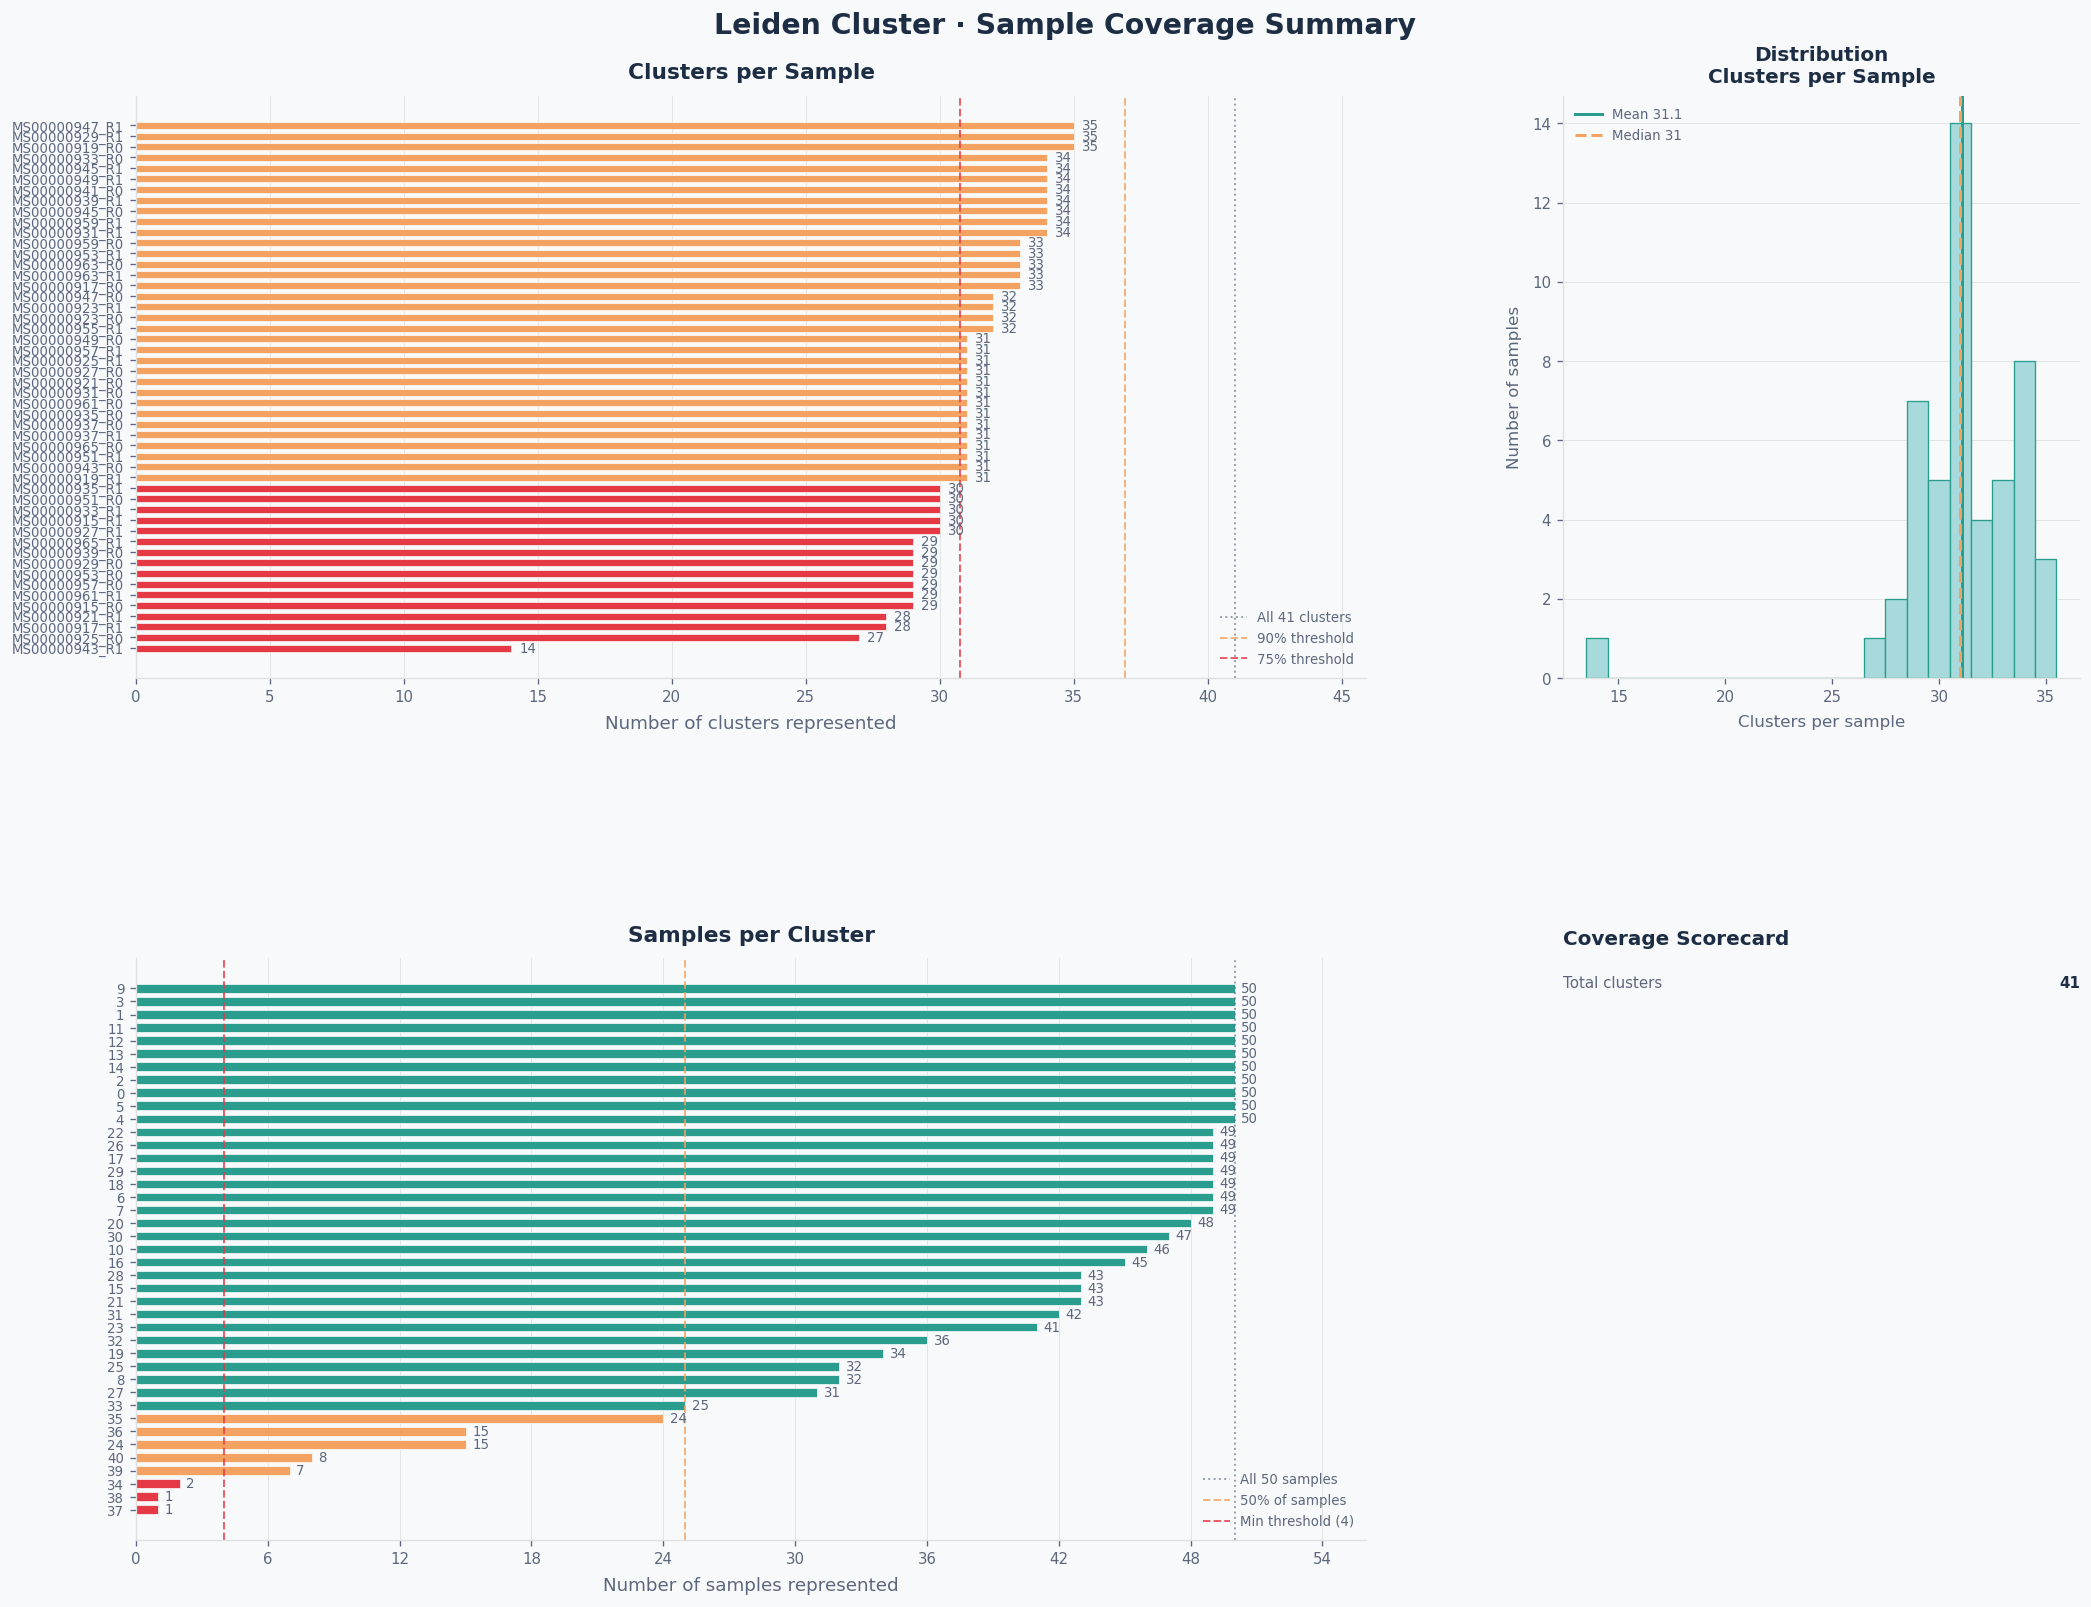

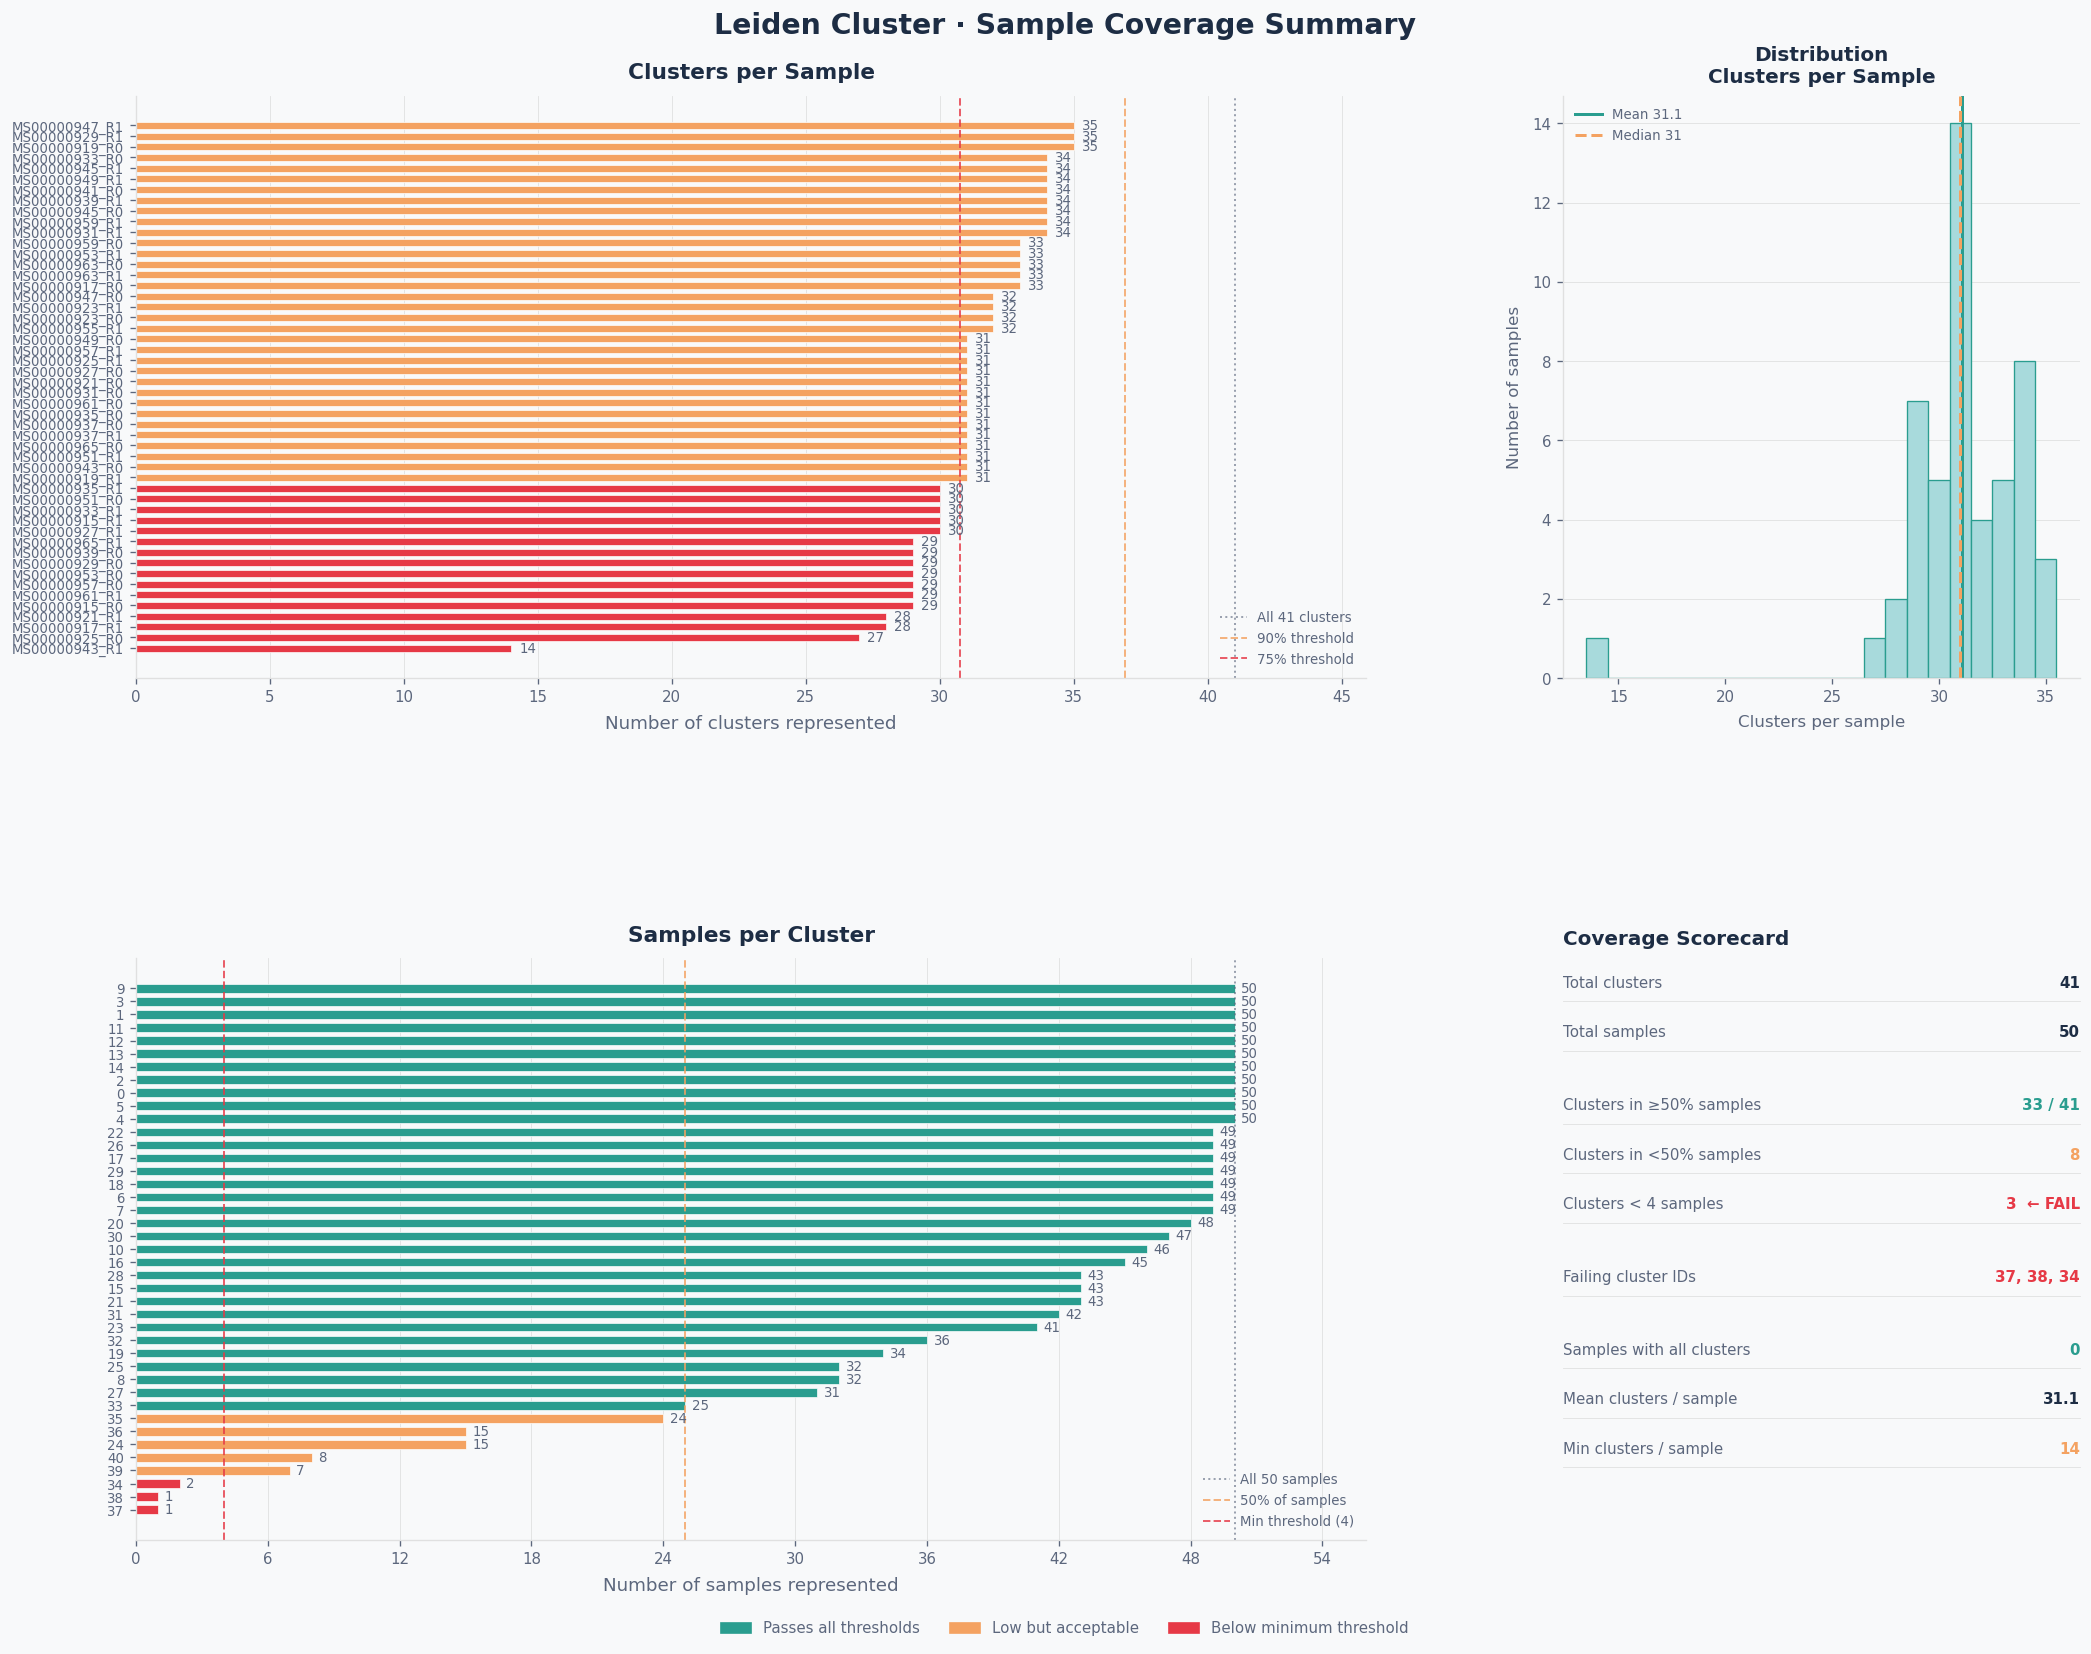

Saved → coverage_summary.png


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

raw = pd.crosstab(
    adata.obs['leiden'].astype(str),
    adata.obs['sample_id'].astype(str)
)

clusters_per_sample = (raw > 0).sum(axis=0).sort_values()
samples_per_cluster = (raw > 0).sum(axis=1).sort_values()
n_donors   = raw.shape[1]
n_clusters = raw.shape[0]
MIN_DONORS = 4

# ── Palette ───────────────────────────────────────────────────────────────────
PASS_DARK   = '#2A9D8F'
PASS_LIGHT  = '#A8DADC'
FAIL_COLOR  = '#E63946'
WARN_COLOR  = '#F4A261'
BG          = '#F8F9FA'
GRID_COLOR  = '#E0E0E0'
TEXT_DARK   = '#1D2D44'
TEXT_MID    = '#5C677D'

def _spine_clean(ax, keep=('bottom', 'left')):
    for s in ['top', 'right', 'bottom', 'left']:
        ax.spines[s].set_visible(s in keep)
    ax.spines['bottom'].set_color(GRID_COLOR)
    ax.spines['left'].set_color(GRID_COLOR)

fig = plt.figure(figsize=(18, 14), facecolor=BG)
fig.suptitle(
    'Leiden Cluster · Sample Coverage Summary',
    fontsize=17, fontweight='bold', color=TEXT_DARK,
    x=0.5, y=0.98, ha='center'
)

gs = gridspec.GridSpec(
    2, 3,
    figure=fig,
    hspace=0.48, wspace=0.38,
    left=0.07, right=0.97, top=0.93, bottom=0.07
)

# ── 1. Clusters per sample (horizontal bar) ───────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_facecolor(BG)

colors_s = [FAIL_COLOR if v < n_clusters * 0.75 else
            WARN_COLOR if v < n_clusters * 0.90 else
            PASS_DARK  for v in clusters_per_sample.values]

bars = ax1.barh(
    clusters_per_sample.index.astype(str),
    clusters_per_sample.values,
    color=colors_s, height=0.65,
    edgecolor='white', linewidth=0.4
)

ax1.axvline(n_clusters, color=TEXT_MID, lw=1.2, ls=':', alpha=0.6, label=f'All {n_clusters} clusters')
ax1.axvline(n_clusters * 0.9, color=WARN_COLOR, lw=1.2, ls='--', alpha=0.8, label='90% threshold')
ax1.axvline(n_clusters * 0.75, color=FAIL_COLOR, lw=1.2, ls='--', alpha=0.8, label='75% threshold')

for bar, val in zip(bars, clusters_per_sample.values):
    ax1.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
             str(val), va='center', ha='left', fontsize=8, color=TEXT_MID)

ax1.set_xlabel('Number of clusters represented', fontsize=11, color=TEXT_MID, labelpad=6)
ax1.set_title('Clusters per Sample', fontsize=13, fontweight='bold', color=TEXT_DARK, pad=10)
ax1.set_xlim(0, n_clusters * 1.12)
ax1.tick_params(axis='y', labelsize=8, colors=TEXT_MID)
ax1.tick_params(axis='x', labelsize=9, colors=TEXT_MID)
ax1.legend(fontsize=8, frameon=False, loc='lower right', labelcolor=TEXT_MID)
ax1.set_facecolor(BG)
ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
_spine_clean(ax1)
ax1.yaxis.grid(False)
ax1.xaxis.grid(True, color=GRID_COLOR, lw=0.5, zorder=0)
ax1.set_axisbelow(True)

# ── 2. Distribution of clusters-per-sample (histogram) ───────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor(BG)

bins = np.arange(clusters_per_sample.min() - 0.5,
                 clusters_per_sample.max() + 1.5, 1)
ax2.hist(clusters_per_sample.values, bins=bins,
         color=PASS_LIGHT, edgecolor=PASS_DARK, linewidth=0.8)
ax2.axvline(clusters_per_sample.mean(), color=PASS_DARK, lw=1.8,
            ls='-', label=f'Mean {clusters_per_sample.mean():.1f}')
ax2.axvline(clusters_per_sample.median(), color=WARN_COLOR, lw=1.8,
            ls='--', label=f'Median {clusters_per_sample.median():.0f}')

ax2.set_xlabel('Clusters per sample', fontsize=10, color=TEXT_MID, labelpad=6)
ax2.set_ylabel('Number of samples', fontsize=10, color=TEXT_MID, labelpad=6)
ax2.set_title('Distribution\nClusters per Sample', fontsize=12,
              fontweight='bold', color=TEXT_DARK, pad=8)
ax2.legend(fontsize=8, frameon=False, labelcolor=TEXT_MID)
ax2.tick_params(labelsize=9, colors=TEXT_MID)
_spine_clean(ax2)
ax2.yaxis.grid(True, color=GRID_COLOR, lw=0.5, zorder=0)
ax2.set_axisbelow(True)

# ── 3. Samples per cluster (horizontal bar) ───────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
ax3.set_facecolor(BG)

colors_c = [FAIL_COLOR if v < MIN_DONORS else
            WARN_COLOR if v < n_donors * 0.5 else
            PASS_DARK  for v in samples_per_cluster.values]

bars3 = ax3.barh(
    samples_per_cluster.index.astype(str),
    samples_per_cluster.values,
    color=colors_c, height=0.65,
    edgecolor='white', linewidth=0.4
)

ax3.axvline(n_donors,       color=TEXT_MID,   lw=1.2, ls=':',  alpha=0.6, label=f'All {n_donors} samples')
ax3.axvline(n_donors * 0.5, color=WARN_COLOR, lw=1.2, ls='--', alpha=0.8, label='50% of samples')
ax3.axvline(MIN_DONORS,     color=FAIL_COLOR, lw=1.2, ls='--', alpha=0.8, label=f'Min threshold ({MIN_DONORS})')

for bar, val in zip(bars3, samples_per_cluster.values):
    ax3.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
             str(val), va='center', ha='left', fontsize=8, color=TEXT_MID)

ax3.set_xlabel('Number of samples represented', fontsize=11, color=TEXT_MID, labelpad=6)
ax3.set_title('Samples per Cluster', fontsize=13, fontweight='bold', color=TEXT_DARK, pad=10)
ax3.set_xlim(0, n_donors * 1.12)
ax3.tick_params(axis='y', labelsize=8, colors=TEXT_MID)
ax3.tick_params(axis='x', labelsize=9, colors=TEXT_MID)
ax3.legend(fontsize=8, frameon=False, loc='lower right', labelcolor=TEXT_MID)
ax3.set_facecolor(BG)
ax3.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
_spine_clean(ax3)
ax3.yaxis.grid(False)
ax3.xaxis.grid(True, color=GRID_COLOR, lw=0.5, zorder=0)
ax3.set_axisbelow(True)

# ── 4. Summary scorecard ──────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
ax4.set_facecolor(BG)
ax4.axis('off')

failing_clusters = samples_per_cluster[samples_per_cluster < MIN_DONORS]
warn_clusters    = samples_per_cluster[(samples_per_cluster >= MIN_DONORS) &
                                        (samples_per_cluster < n_donors * 0.5)]

stats = [
    ('Total clusters',          f'{n_clusters}',                          TEXT_DARK),
    ('Total samples',           f'{n_donors}',                            TEXT_DARK),
    ('',                        '',                                        TEXT_DARK),
    ('Clusters in ≥50% samples',f'{(samples_per_cluster >= n_donors*0.5).sum()} / {n_clusters}', PASS_DARK),
    ('Clusters in <50% samples',f'{(samples_per_cluster < n_donors*0.5).sum()}',                  WARN_COLOR),
    (f'Clusters < {MIN_DONORS} samples', f'{len(failing_clusters)}  ← FAIL', FAIL_COLOR),
    ('',                        '',                                        TEXT_DARK),
    ('Failing cluster IDs',     ', '.join(failing_clusters.index.tolist()) or 'None', FAIL_COLOR),
    ('',                        '',                                        TEXT_DARK),
    ('Samples with all clusters',f'{(clusters_per_sample == n_clusters).sum()}', PASS_DARK),
    ('Mean clusters / sample',  f'{clusters_per_sample.mean():.1f}',      TEXT_DARK),
    ('Min clusters / sample',   f'{clusters_per_sample.min()}',           WARN_COLOR),
]

ax4.set_title('Coverage Scorecard', fontsize=12, fontweight='bold',
              color=TEXT_DARK, pad=8, loc='left')

y = 0.97
for label, value, color in stats:
    if label == '':
        y -= 0.04
        continue
    ax4.text(0.0, y, label, transform=ax4.transAxes,
             fontsize=9, color=TEXT_MID, va='top')
    ax4.text(1.0, y, value, transform=ax4.transAxes,
             fontsize=9, color=color, va='top', ha='right', fontweight='bold')
    y -= 0.085
    ax4.plot([0, 1], [y + 0.04, y + 0.04],
             color=GRID_COLOR, lw=0.5, transform=ax4.transAxes, clip_on=False)

# ── Legend patches ────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color=PASS_DARK,  label='Passes all thresholds'),
    mpatches.Patch(color=WARN_COLOR, label='Low but acceptable'),
    mpatches.Patch(color=FAIL_COLOR, label='Below minimum threshold'),
]
fig.legend(handles=legend_patches, loc='lower center',
           ncol=3, fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, 0.005), labelcolor=TEXT_MID)

plt.savefig('coverage_summary.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved → coverage_summary.png")

## Shannon Entropy per Cluster (Per-cluster mixing score)
Measures how "mixed" each cluster is with respect to a metadata field. A well-integrated cluster has high entropy across batches:

In [4]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

metadata_fields = ['sample_id', 'batch_id', 'leiden', 'slide_id', 'slide_roi', 'bri_id', 'donor', 'anatomical_site', 'vdz_status', 'clinical_response', 'disease', 'batch']

results = {}
for field in metadata_fields:
    # Drop NaN rows for this field
    mask = adata.obs[field].notna()
    leiden = adata.obs.loc[mask, 'leiden']
    meta = adata.obs.loc[mask, field]
    
    results[field] = {
        'NMI': normalized_mutual_info_score(leiden, meta),
        'ARI': adjusted_rand_score(leiden, meta)
    }

results_df = pd.DataFrame(results).T.sort_values('NMI', ascending=False)
print(results_df)

                        NMI       ARI
leiden             1.000000  1.000000
sample_id          0.191903  0.042170
bri_id             0.169676  0.039056
batch_id           0.161350  0.044818
slide_id           0.161350  0.044818
donor              0.143828  0.048441
batch              0.114321  0.040181
anatomical_site    0.092416  0.024243
disease            0.077823  0.019029
slide_roi          0.024578  0.006189
clinical_response  0.021950  0.006929
vdz_status         0.021364  0.004676


Looking at your table, the story is pretty clear: no strong technical or biological signal is driving your clusters — all NMI values are low (<0.11), and ARI values are near zero. sample_id is the strongest correlate, which could indicate mild sample-level effects, but nothing is alarming. disease and clinical_response are very low, suggesting clusters aren't simply capturing disease state either — which likely means you're resolving cell types, not condition effects. Good news overall.

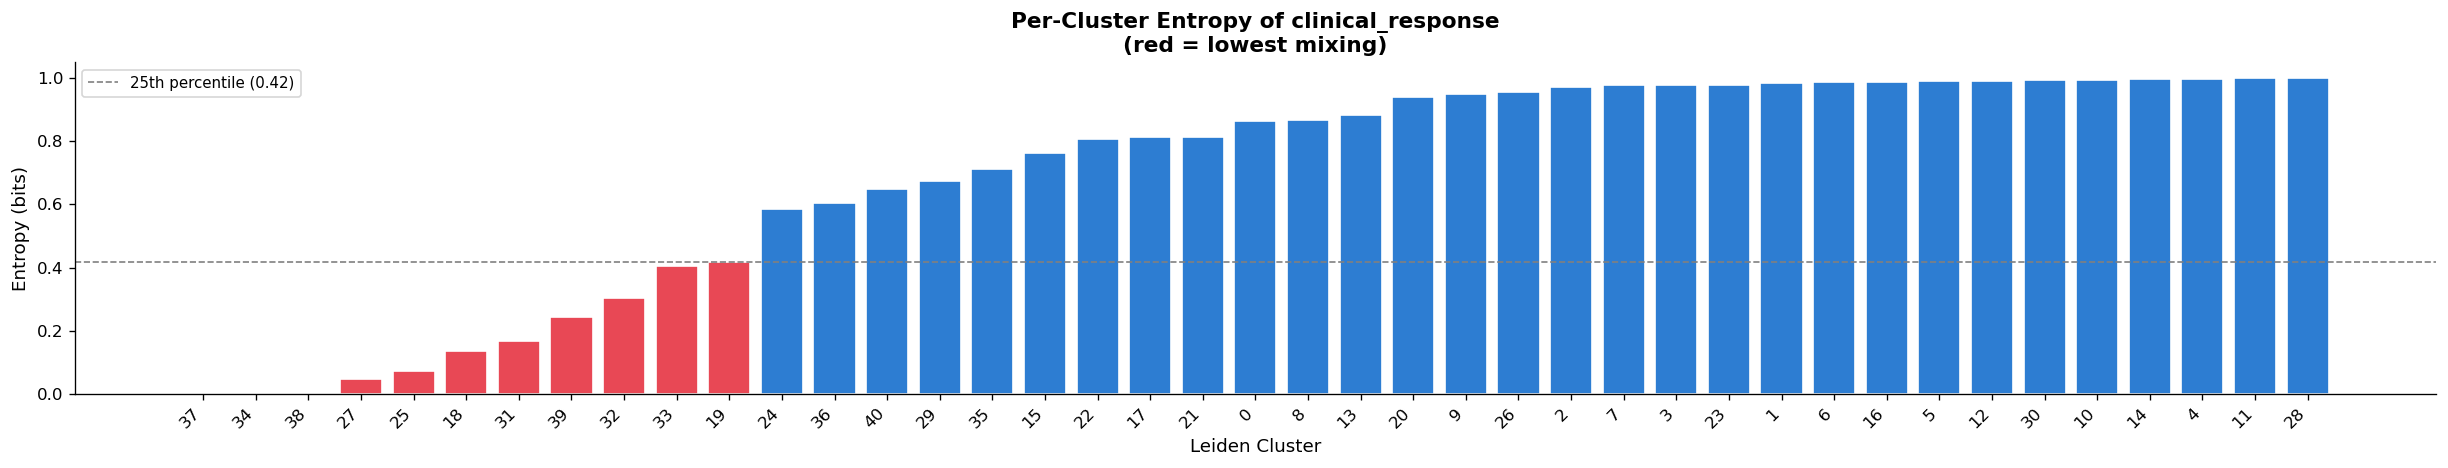

In [35]:
plot_entropy_per_cluster(adata, cluster_key='leiden', meta_key='clinical_response')

In [ ]:
adata.write('Final_clustered_adata_030526.h5ad')

Cluster dtype: category
Sample dtype: object
Unique clusters: ['11', '0', '4', '15', '20', '9', '5', '6', '2', '7']
Categories (41, object): ['0', '1', '2', '3', ..., '37', '38', '39', '40']
Count matrix index: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Count matrix dtypes: object
Thresholds — min_cells: 1  |  min_frac: 0.1%
Total pairs: 2050  |  Present: 908  |  Missing: 1142

── Per-Sample Coverage ──────────────────────────────────────────
               clusters_present_in  clusters_missing_from  pct_coverage  total_cells
sample_id                                                                           
MS00000925_R1                   12                     29     29.268293       224393
MS00000943_R1                   14                     27     34.146341          447
MS00000939_R1                   15                     26     36.585366        79230
MS00000935_R1                   15                     26     36.585366        89428
MS00000933_R1                   15 

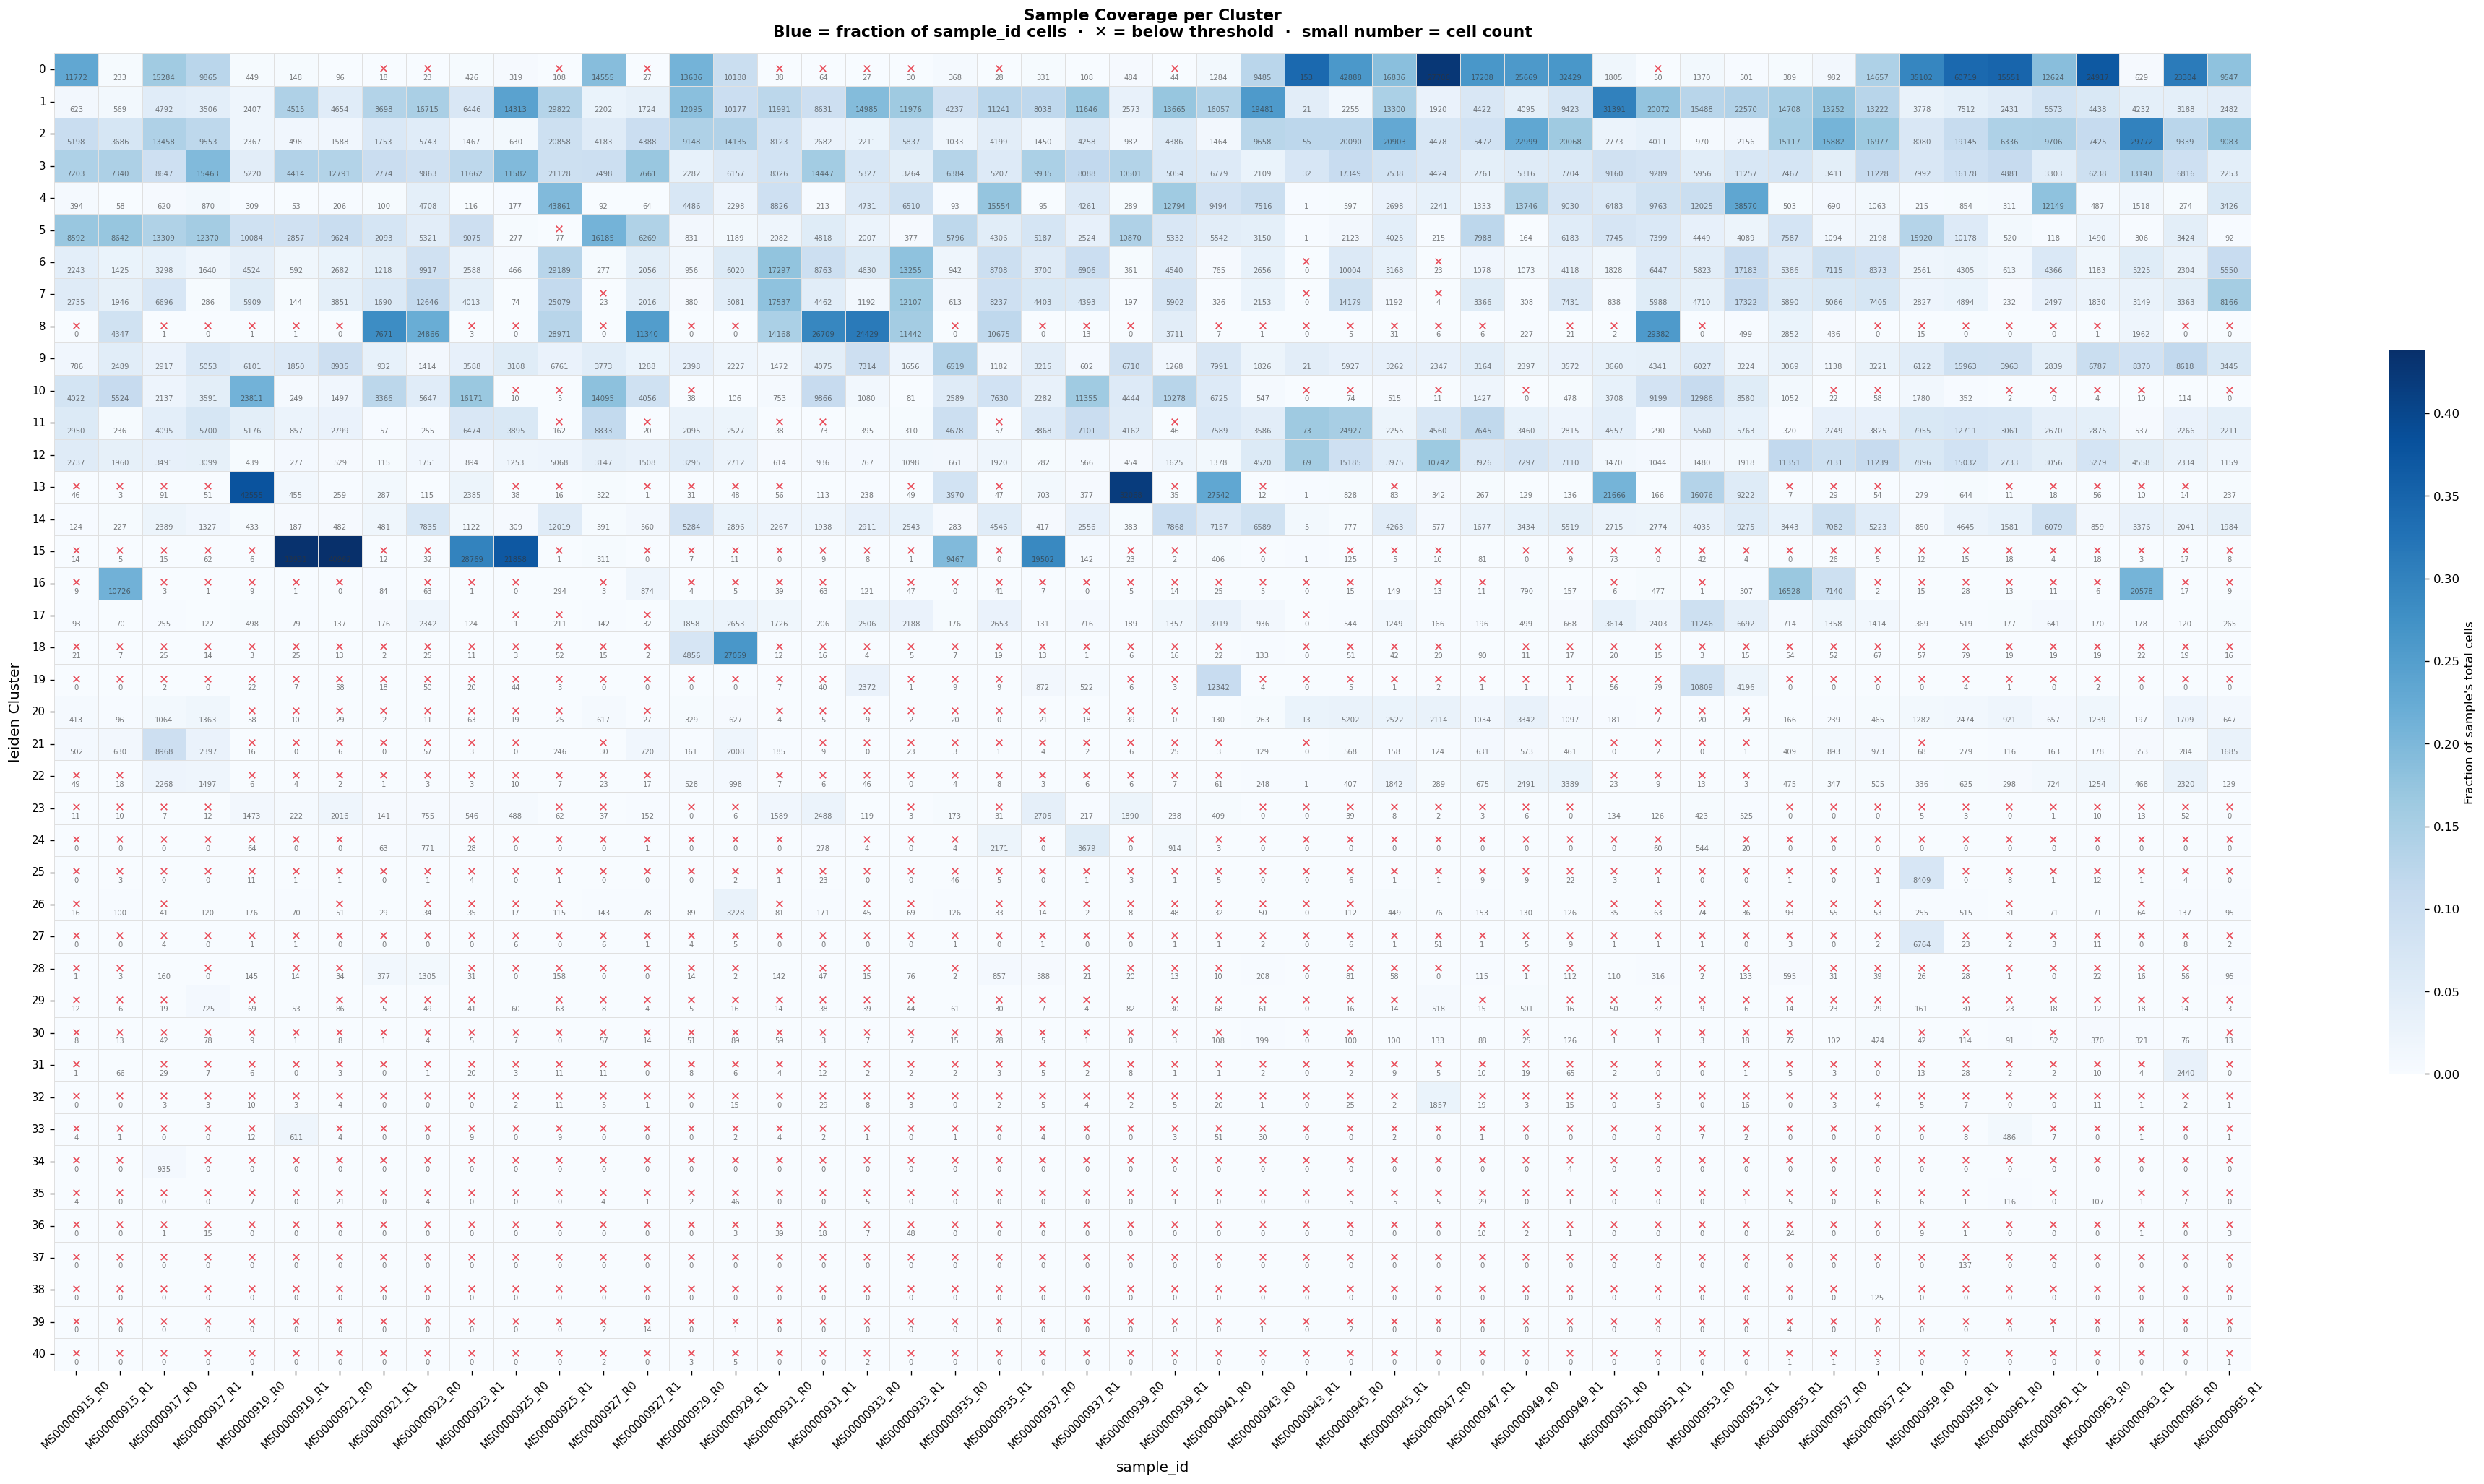

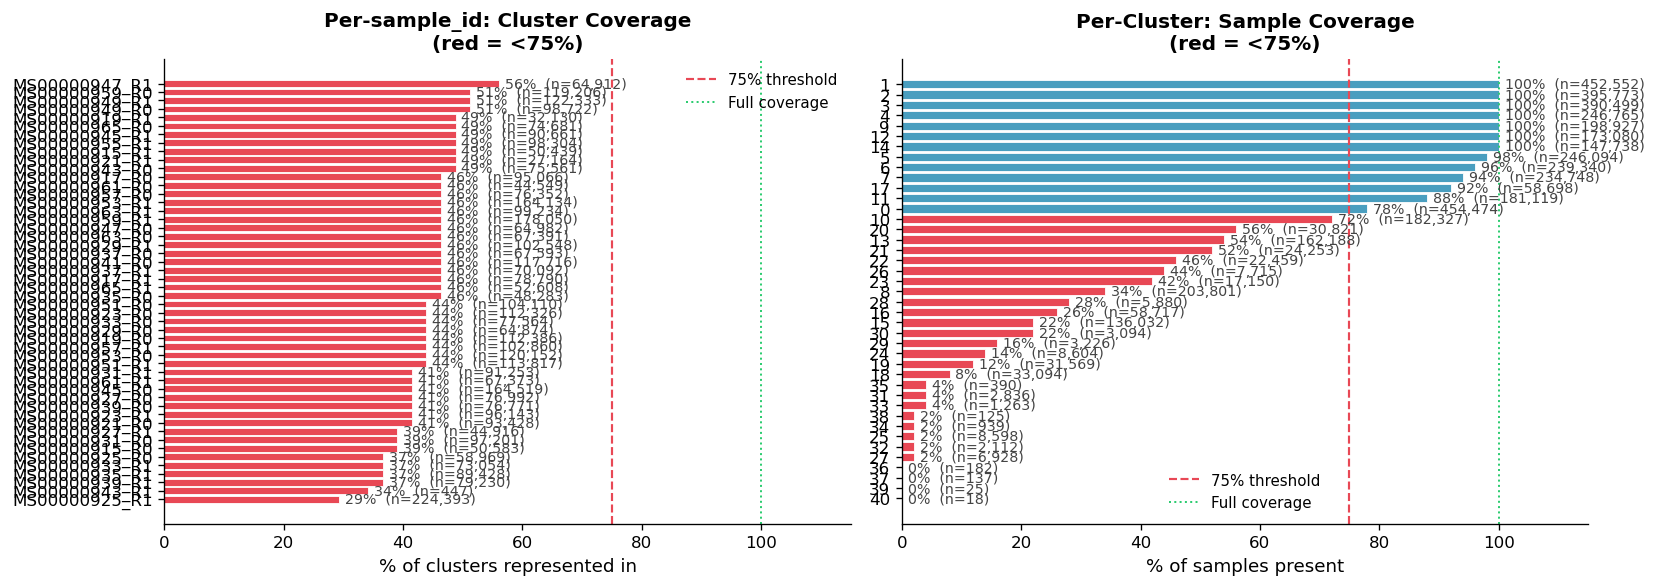

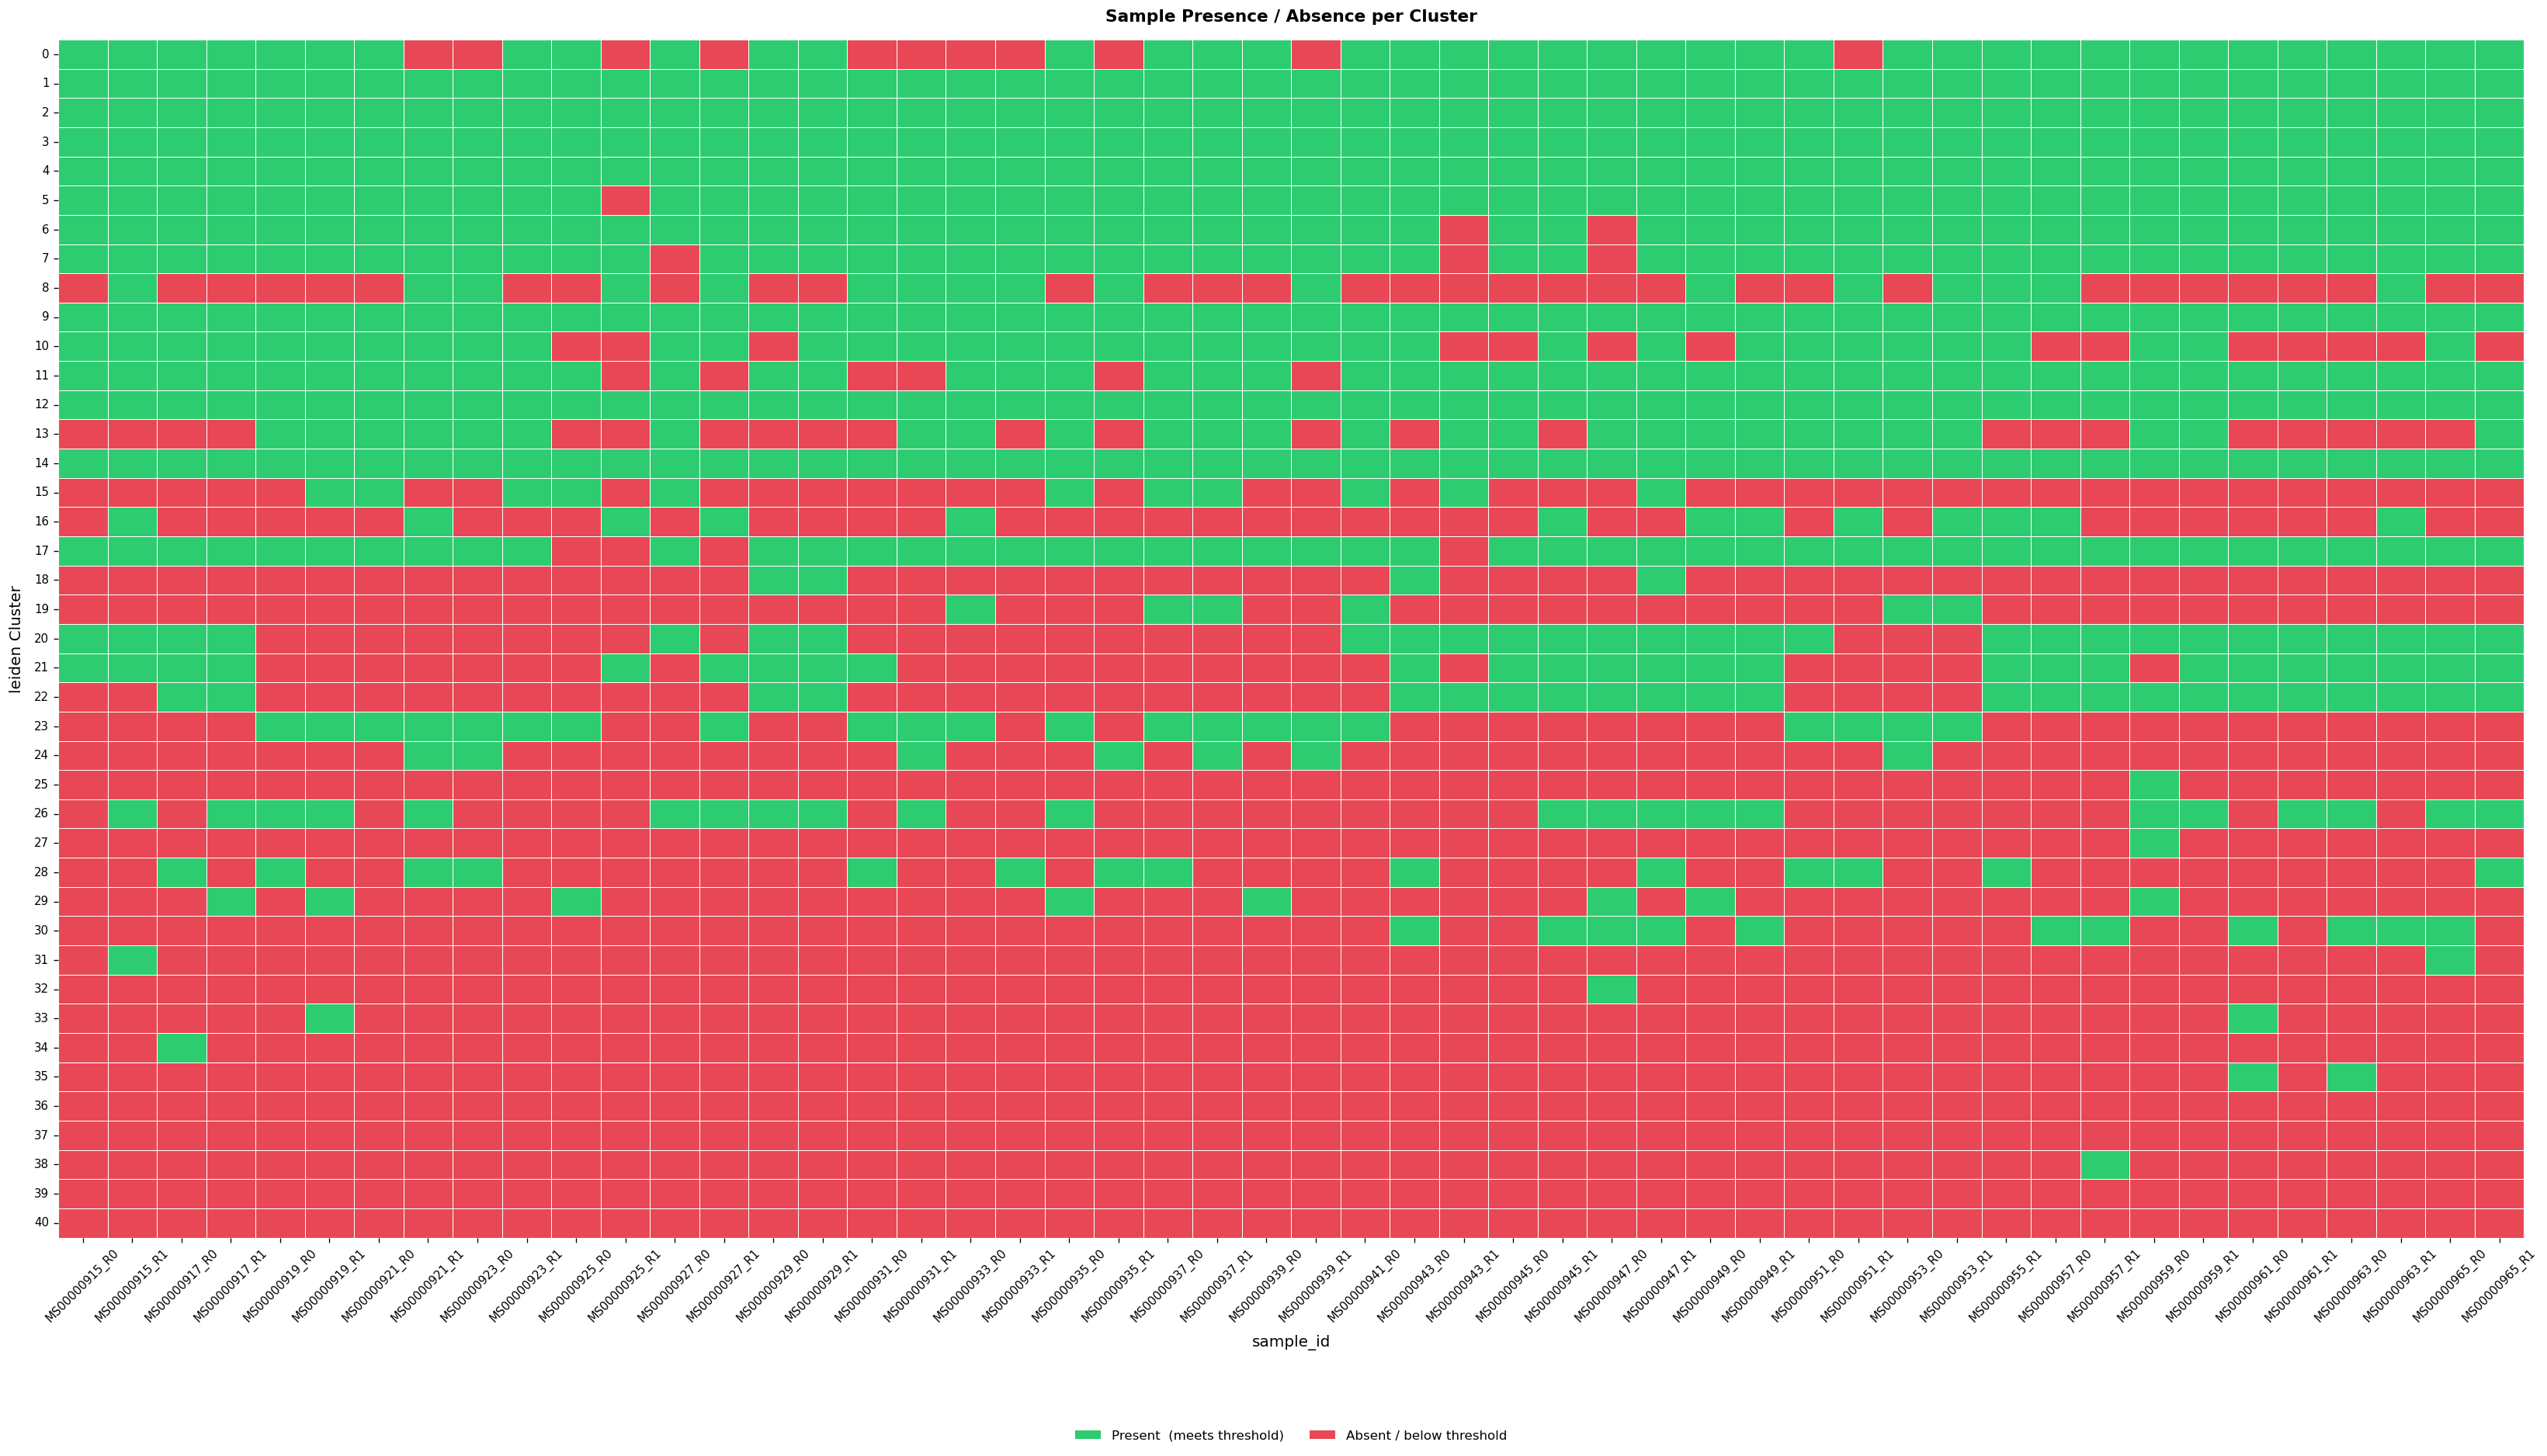

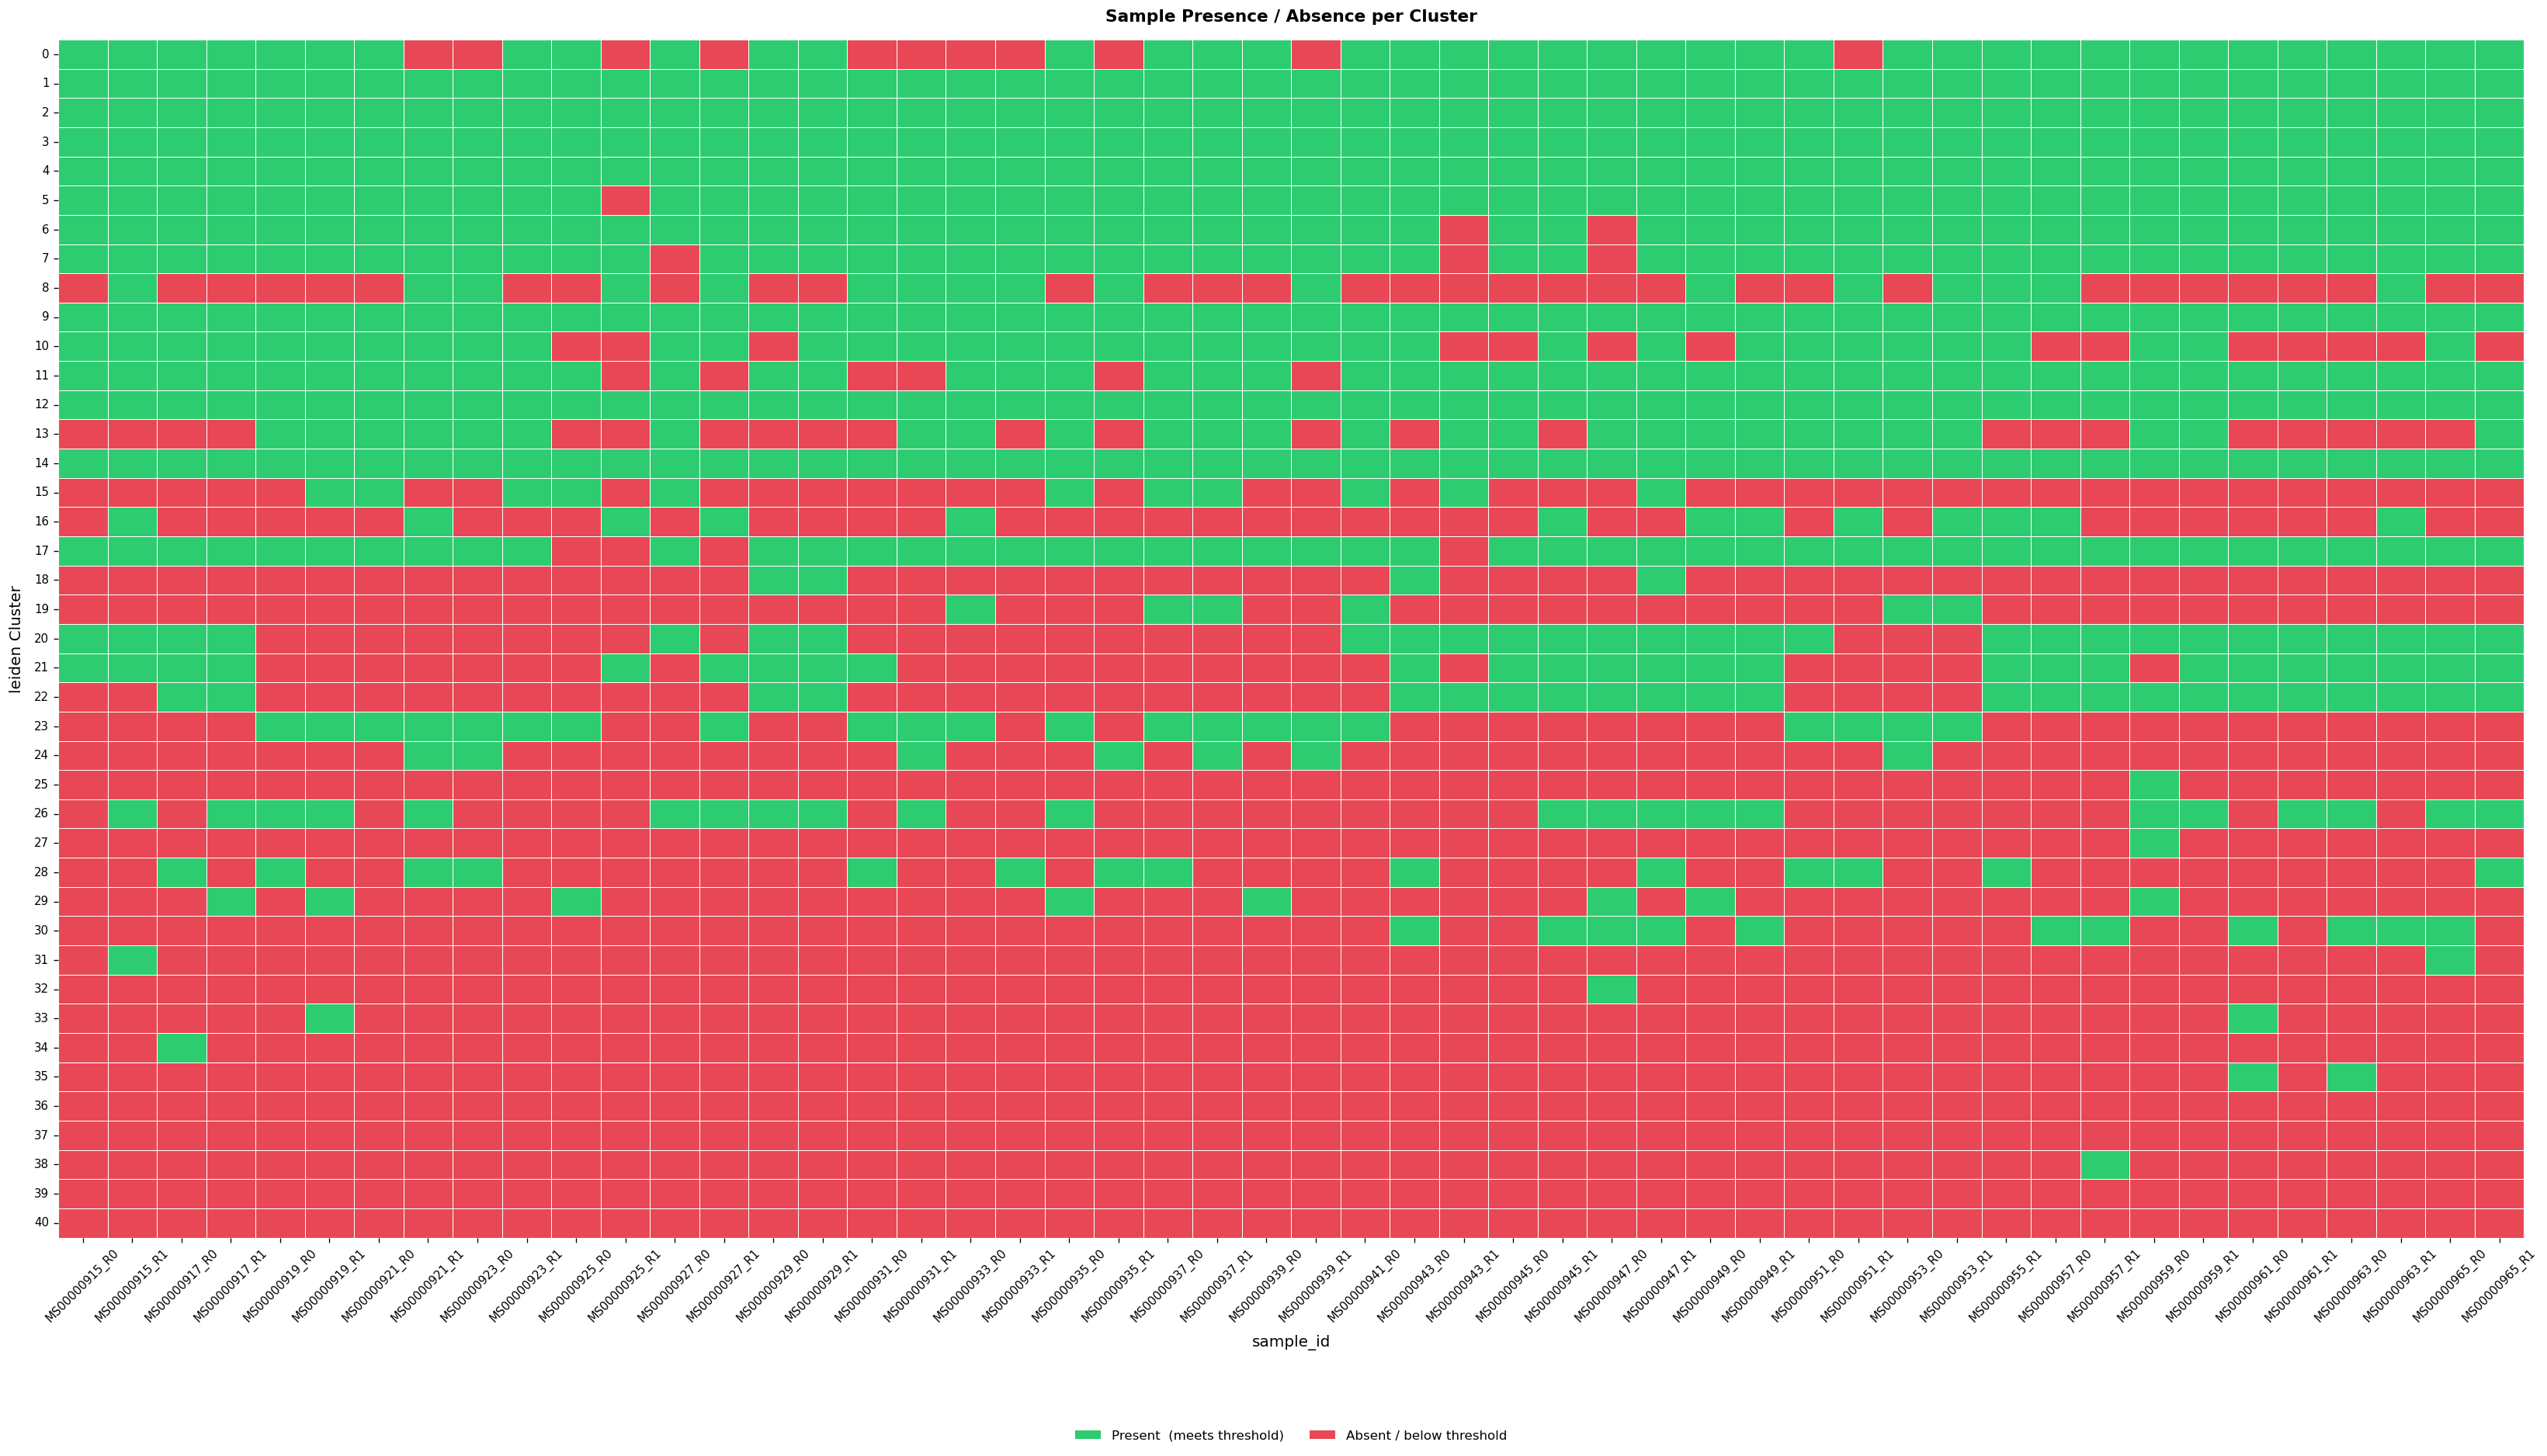

In [26]:
# ── Cell 7: Run everything ────────────────────────────────────────────────────
# Adjust these to match your adata and desired stringency
CLUSTER_KEY = 'leiden'
SAMPLE_KEY  = 'sample_id'
MIN_CELLS   = 1      # sample must have ≥ this many cells in a cluster
MIN_FRAC    = 0.001   # those cells must be ≥ 1% of the sample's total cells

matrices = build_coverage_matrices(
    adata,
    cluster_key=CLUSTER_KEY,
    sample_key=SAMPLE_KEY,
    min_cells=MIN_CELLS,
    min_frac=MIN_FRAC,
)

summary = summarise_coverage(matrices, min_cells=MIN_CELLS, min_frac=MIN_FRAC)

plot_presence_heatmap(matrices, cluster_key=CLUSTER_KEY, sample_key=SAMPLE_KEY)
plot_coverage_bars(summary, sample_key=SAMPLE_KEY)
plot_presence_absence(matrices, cluster_key=CLUSTER_KEY, sample_key=SAMPLE_KEY)

In [37]:
adata_low = sc.read_h5ad('/home/workspace/private/working/Final_clustered_adata_030526.h5ad')
adata_med = sc.read_h5ad('/home/workspace/private/working/R05clustered_adata_031026.h5ad')
adata_high = sc.read_h5ad('/home/workspace/private/working/R1clustered_adata_031026.h5ad')

In [39]:
adata_mid = adata_med

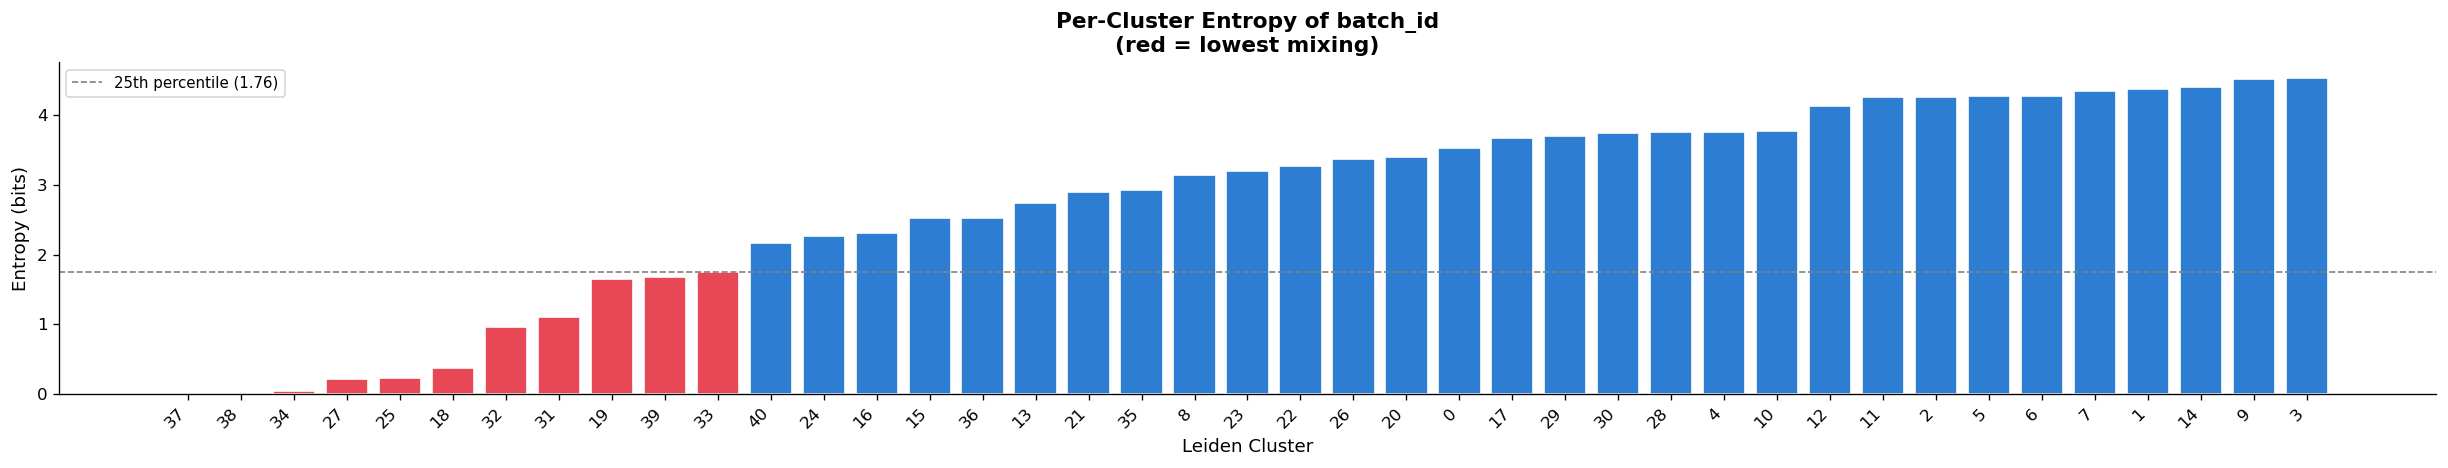

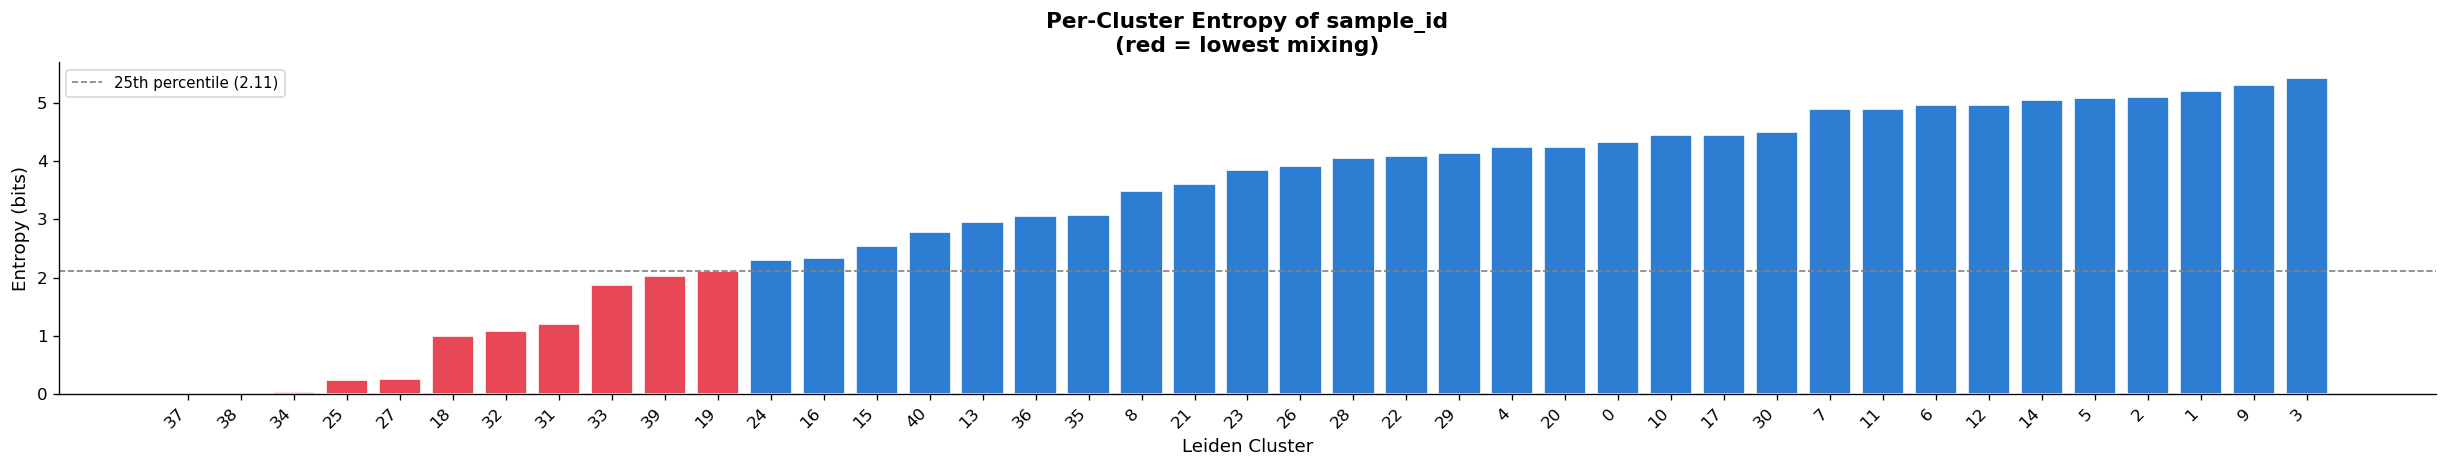

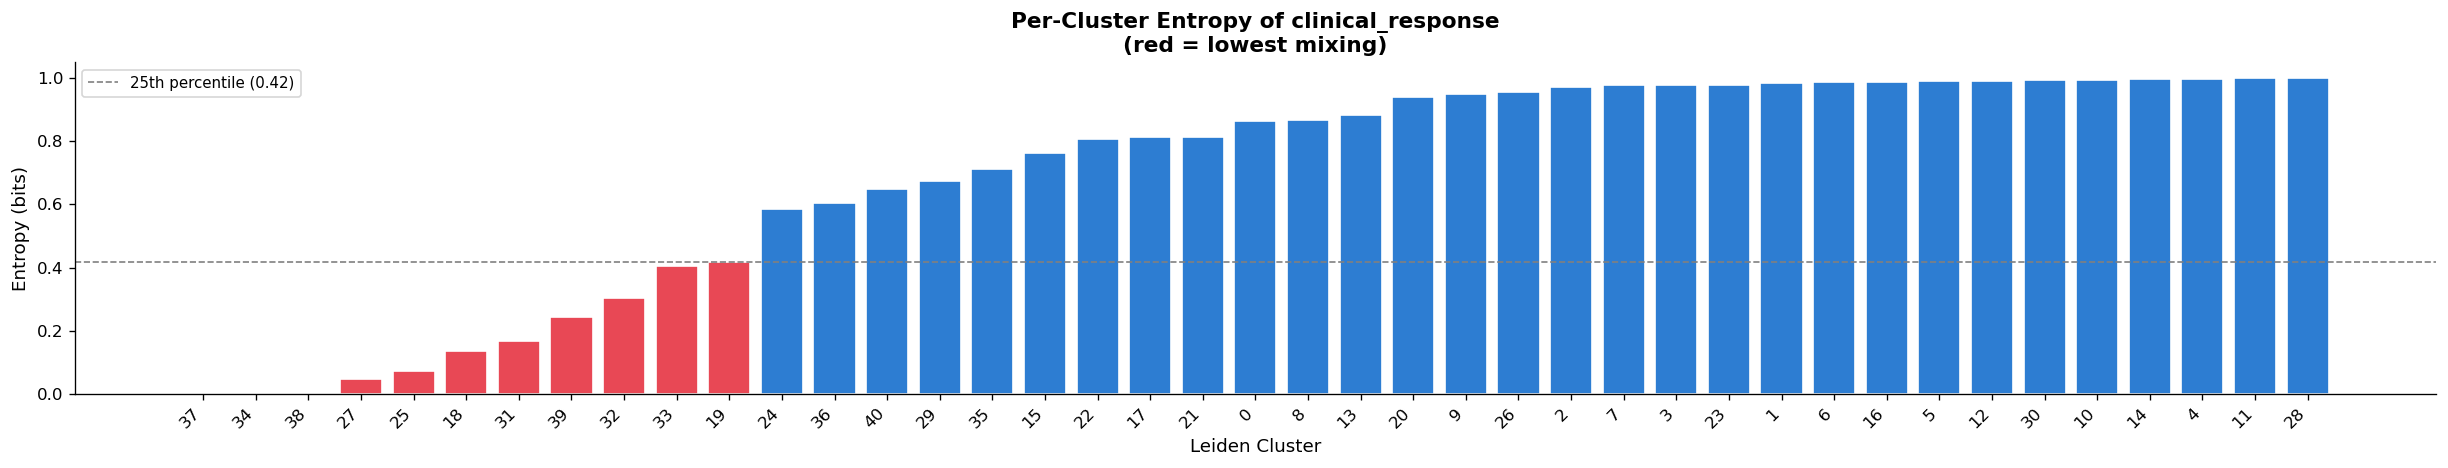

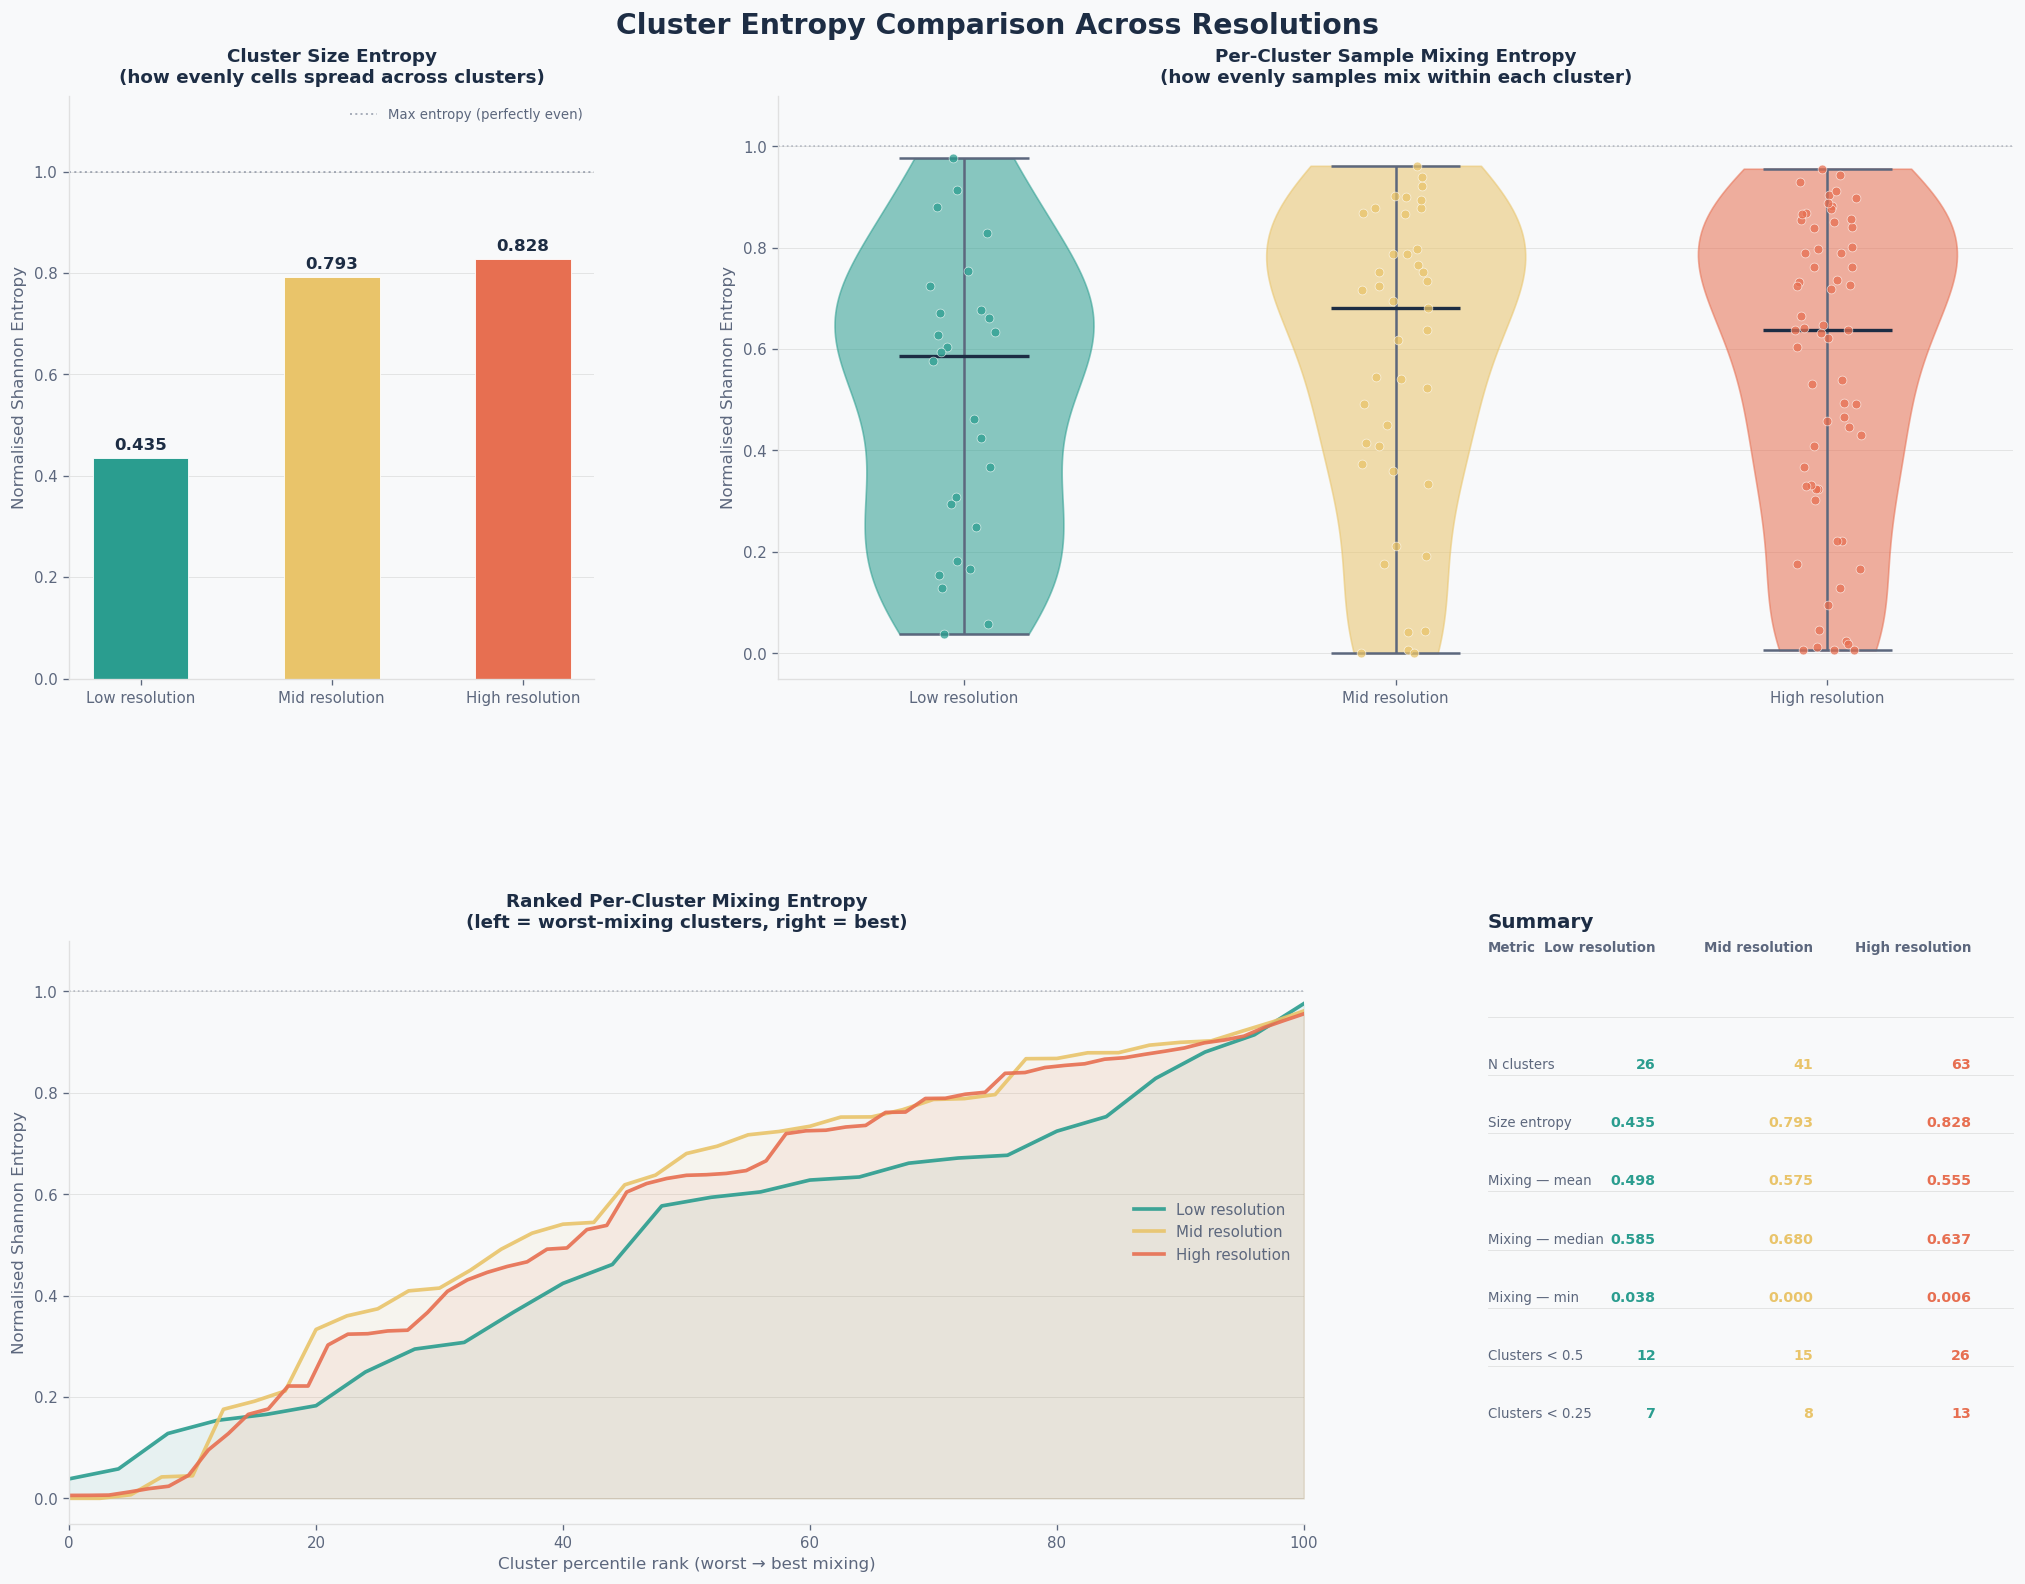

Saved → entropy_comparison.png


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import entropy
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Define your objects and labels ────────────────────────────────────────────
adatas = {
    'Low resolution':    adata_low,
    'Mid resolution':    adata_mid,
    'High resolution':   adata_high,
}
CLUSTER_KEY = 'leiden'
SAMPLE_KEY  = 'sample_id'

# ── Palette ───────────────────────────────────────────────────────────────────
BG         = '#F8F9FA'
TEXT_DARK  = '#1D2D44'
TEXT_MID   = '#5C677D'
GRID_COLOR = '#E0E0E0'
COLORS     = ['#2A9D8F', '#E9C46A', '#E76F51']  # one per resolution

def _spine_clean(ax):
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)
    ax.spines['bottom'].set_color(GRID_COLOR)
    ax.spines['left'].set_color(GRID_COLOR)

# ── Compute entropy metrics ───────────────────────────────────────────────────
def compute_entropies(adata, cluster_key, sample_key):
    raw = pd.crosstab(
        adata.obs[cluster_key].astype(str),
        adata.obs[sample_key].astype(str),
    )
    n_clusters = raw.shape[0]
    n_samples  = raw.shape[1]

    # 1. Cluster size entropy — how evenly cells spread across clusters
    #    Normalised by log(n_clusters) so max = 1.0
    cluster_sizes = raw.sum(axis=1)
    cluster_size_probs = cluster_sizes / cluster_sizes.sum()
    size_entropy = entropy(cluster_size_probs) / np.log(n_clusters)

    # 2. Per-cluster sample mixing entropy — for each cluster, how evenly
    #    are the samples represented? Normalised by log(n_samples).
    per_cluster_entropy = {}
    for cluster in raw.index:
        counts = raw.loc[cluster]
        counts = counts[counts > 0]               # drop absent samples
        probs  = counts / counts.sum()
        h      = entropy(probs) / np.log(n_samples)
        per_cluster_entropy[cluster] = h

    per_cluster_entropy = pd.Series(per_cluster_entropy, name='entropy')

    return {
        'size_entropy':        size_entropy,
        'per_cluster_entropy': per_cluster_entropy,
        'n_clusters':          n_clusters,
        'cluster_sizes':       cluster_sizes,
        'raw':                 raw,
    }

results = {label: compute_entropies(ad, CLUSTER_KEY, SAMPLE_KEY)
           for label, ad in adatas.items()}

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14), facecolor=BG)
fig.suptitle('Cluster Entropy Comparison Across Resolutions',
             fontsize=17, fontweight='bold', color=TEXT_DARK,
             x=0.5, y=0.98, ha='center')

gs = gridspec.GridSpec(2, 3, figure=fig,
                       hspace=0.45, wspace=0.35,
                       left=0.07, right=0.97, top=0.93, bottom=0.08)

labels  = list(results.keys())
colors  = COLORS

# ── 1. Cluster size entropy — single bar per resolution ───────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(BG)

size_entropies = [results[l]['size_entropy'] for l in labels]
bars = ax1.bar(labels, size_entropies, color=colors,
               edgecolor='white', linewidth=0.5, width=0.5)
ax1.axhline(1.0, color=TEXT_MID, lw=1.2, ls=':', alpha=0.5, label='Max entropy (perfectly even)')
for bar, val in zip(bars, size_entropies):
    ax1.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10,
             color=TEXT_DARK, fontweight='bold')

ax1.set_ylim(0, 1.15)
ax1.set_ylabel('Normalised Shannon Entropy', fontsize=10, color=TEXT_MID)
ax1.set_title('Cluster Size Entropy\n(how evenly cells spread across clusters)',
              fontsize=11, fontweight='bold', color=TEXT_DARK, pad=8)
ax1.tick_params(labelsize=9, colors=TEXT_MID)
ax1.legend(fontsize=8, frameon=False, labelcolor=TEXT_MID)
_spine_clean(ax1)
ax1.yaxis.grid(True, color=GRID_COLOR, lw=0.5, zorder=0)
ax1.set_axisbelow(True)

# ── 2. Per-cluster sample mixing entropy — violin/strip per resolution ─────────
ax2 = fig.add_subplot(gs[0, 1:])
ax2.set_facecolor(BG)

violin_data = [results[l]['per_cluster_entropy'].values for l in labels]
parts = ax2.violinplot(violin_data, positions=range(len(labels)),
                       showmedians=True, showextrema=True, widths=0.6)

for i, (pc, color) in enumerate(zip(parts['bodies'], colors)):
    pc.set_facecolor(color)
    pc.set_alpha(0.55)
    pc.set_edgecolor(color)

parts['cmedians'].set_color(TEXT_DARK)
parts['cmedians'].set_linewidth(2)
parts['cmins'].set_color(TEXT_MID)
parts['cmaxes'].set_color(TEXT_MID)
parts['cbars'].set_color(TEXT_MID)

# Overlay individual cluster dots
for i, (label, color) in enumerate(zip(labels, colors)):
    vals = results[label]['per_cluster_entropy'].values
    jitter = np.random.uniform(-0.08, 0.08, size=len(vals))
    ax2.scatter(i + jitter, vals, color=color, alpha=0.75,
                s=28, edgecolors='white', linewidths=0.4, zorder=3)

ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, fontsize=10, color=TEXT_MID)
ax2.set_ylabel('Normalised Shannon Entropy', fontsize=10, color=TEXT_MID)
ax2.set_title('Per-Cluster Sample Mixing Entropy\n(how evenly samples mix within each cluster)',
              fontsize=11, fontweight='bold', color=TEXT_DARK, pad=8)
ax2.set_ylim(-0.05, 1.1)
ax2.axhline(1.0, color=TEXT_MID, lw=1.0, ls=':', alpha=0.4)
ax2.tick_params(labelsize=9, colors=TEXT_MID)
_spine_clean(ax2)
ax2.yaxis.grid(True, color=GRID_COLOR, lw=0.5, zorder=0)
ax2.set_axisbelow(True)

# ── 3. Per-cluster entropy ranked — one line per resolution ───────────────────
ax3 = fig.add_subplot(gs[1, :2])
ax3.set_facecolor(BG)

for label, color in zip(labels, colors):
    vals = results[label]['per_cluster_entropy'].sort_values().values
    x    = np.linspace(0, 100, len(vals))          # percentile rank
    ax3.plot(x, vals, color=color, lw=2.2, label=label, alpha=0.9)
    ax3.fill_between(x, vals, alpha=0.08, color=color)

ax3.axhline(1.0, color=TEXT_MID, lw=1.0, ls=':', alpha=0.4)
ax3.set_xlabel('Cluster percentile rank (worst → best mixing)', fontsize=10, color=TEXT_MID)
ax3.set_ylabel('Normalised Shannon Entropy', fontsize=10, color=TEXT_MID)
ax3.set_title('Ranked Per-Cluster Mixing Entropy\n(left = worst-mixing clusters, right = best)',
              fontsize=11, fontweight='bold', color=TEXT_DARK, pad=8)
ax3.set_xlim(0, 100)
ax3.set_ylim(-0.05, 1.1)
ax3.legend(fontsize=9, frameon=False, labelcolor=TEXT_MID)
ax3.tick_params(labelsize=9, colors=TEXT_MID)
_spine_clean(ax3)
ax3.yaxis.grid(True, color=GRID_COLOR, lw=0.5, zorder=0)
ax3.set_axisbelow(True)

# ── 4. Scorecard ──────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
ax4.set_facecolor(BG)
ax4.axis('off')
ax4.set_title('Summary', fontsize=12, fontweight='bold',
              color=TEXT_DARK, pad=8, loc='left')

headers = ['Metric'] + labels
col_x   = [0.0, 0.32, 0.62, 0.92]

# Header row
for x, h in zip(col_x, headers):
    ax4.text(x, 1.0, h, transform=ax4.transAxes,
             fontsize=8, color=TEXT_MID, va='top',
             fontweight='bold', ha='left' if x == 0 else 'right')

rows = [
    ('N clusters',       [str(results[l]['n_clusters'])                               for l in labels]),
    ('Size entropy',     [f"{results[l]['size_entropy']:.3f}"                         for l in labels]),
    ('Mixing — mean',    [f"{results[l]['per_cluster_entropy'].mean():.3f}"            for l in labels]),
    ('Mixing — median',  [f"{results[l]['per_cluster_entropy'].median():.3f}"          for l in labels]),
    ('Mixing — min',     [f"{results[l]['per_cluster_entropy'].min():.3f}"             for l in labels]),
    ('Clusters < 0.5',   [str((results[l]['per_cluster_entropy'] < 0.5).sum())         for l in labels]),
    ('Clusters < 0.25',  [str((results[l]['per_cluster_entropy'] < 0.25).sum())        for l in labels]),
]

y = 0.90
for row_label, vals in rows:
    y -= 0.10
    ax4.plot([0, 1], [y + 0.07, y + 0.07], color=GRID_COLOR,
             lw=0.5, transform=ax4.transAxes, clip_on=False)
    ax4.text(col_x[0], y, row_label, transform=ax4.transAxes,
             fontsize=8, color=TEXT_MID, va='top', ha='left')
    for x, val, color in zip(col_x[1:], vals, colors):
        ax4.text(x, y, val, transform=ax4.transAxes,
                 fontsize=8.5, color=color, va='top', ha='right', fontweight='bold')

plt.savefig('entropy_comparison.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved → entropy_comparison.png")

4,374,290 cells  |  52 markers  |  41 clusters
Computing ANOVA F-statistics ...
Computing cluster specificity ...
Subsampled 50,000 / 4,374,290 cells for silhouette ...
Computing per-marker silhouette scores (this is the slow step) ...
  10/52
  20/52
  30/52
  40/52
  52/52
Saved → marker_informativeness.csv

10 LEAST INFORMATIVE MARKERS


,rank_least_informative,marker,anova_f_statistic,cluster_specificity,silhouette_score,composite_score
0,1,CD8a-c8144BAF750,9041.17,5.199,-0.7514,0.0118
1,2,IDO-D5J4EAF488,801.22,2.066,-0.6876,0.0470
2,3,Ki67-D2H10AF647,37471.18,6.522,-0.6983,0.0754
3,4,CD56-NCAM1-795-AF750,6596.91,1.159,-0.6484,0.0790
4,5,CD103-3904RAF750,1703.61,2.440,-0.6219,0.0955
5,6,HLADR-LN3AF647,18475.66,2.829,-0.6303,0.1039
6,7,TCR-delta-E2E9TAF647,10315.11,10.998,-0.6264,0.1100
7,8,CD3d-EP4426AF647,59747.30,12.194,-0.6814,0.1130
8,9,S100A12-OTI1D1AF488,4717.10,3.441,-0.5886,0.1232
9,10,FoxP3-D2W8EAF647,8638.62,2.037,-0.5899,0.1238



10 MOST INFORMATIVE MARKERS


,rank_least_informative,marker,anova_f_statistic,cluster_specificity,silhouette_score,composite_score
51,52,pSTAT1Ty70158D6AF647,96020.24,272.834,-0.6593,0.4789
50,51,CD20-E7B7TAF647,400942.22,36.000,-0.6599,0.4419
49,50,Periostin-E5F2SAF488,200322.54,76.194,-0.5026,0.4372
48,49,pmTORS2448-49F9AF555,75661.37,1.626,-0.2880,0.3963
47,48,p-NF-kB-178F3AF555,57619.15,79.824,-0.4034,0.3942
46,47,NAkATPaseEP1845Y555,112759.29,3.013,-0.3707,0.3694
45,46,PanCytokAE1AE3AF488,116667.27,13.914,-0.4380,0.3376
44,45,IRF-1-D5E4AF647,13281.14,63.635,-0.4102,0.3325
43,44,SMA-1A4AF488,193500.77,24.529,-0.5775,0.3143
42,43,CD207-7430AF647,42310.65,40.279,-0.4334,0.3114


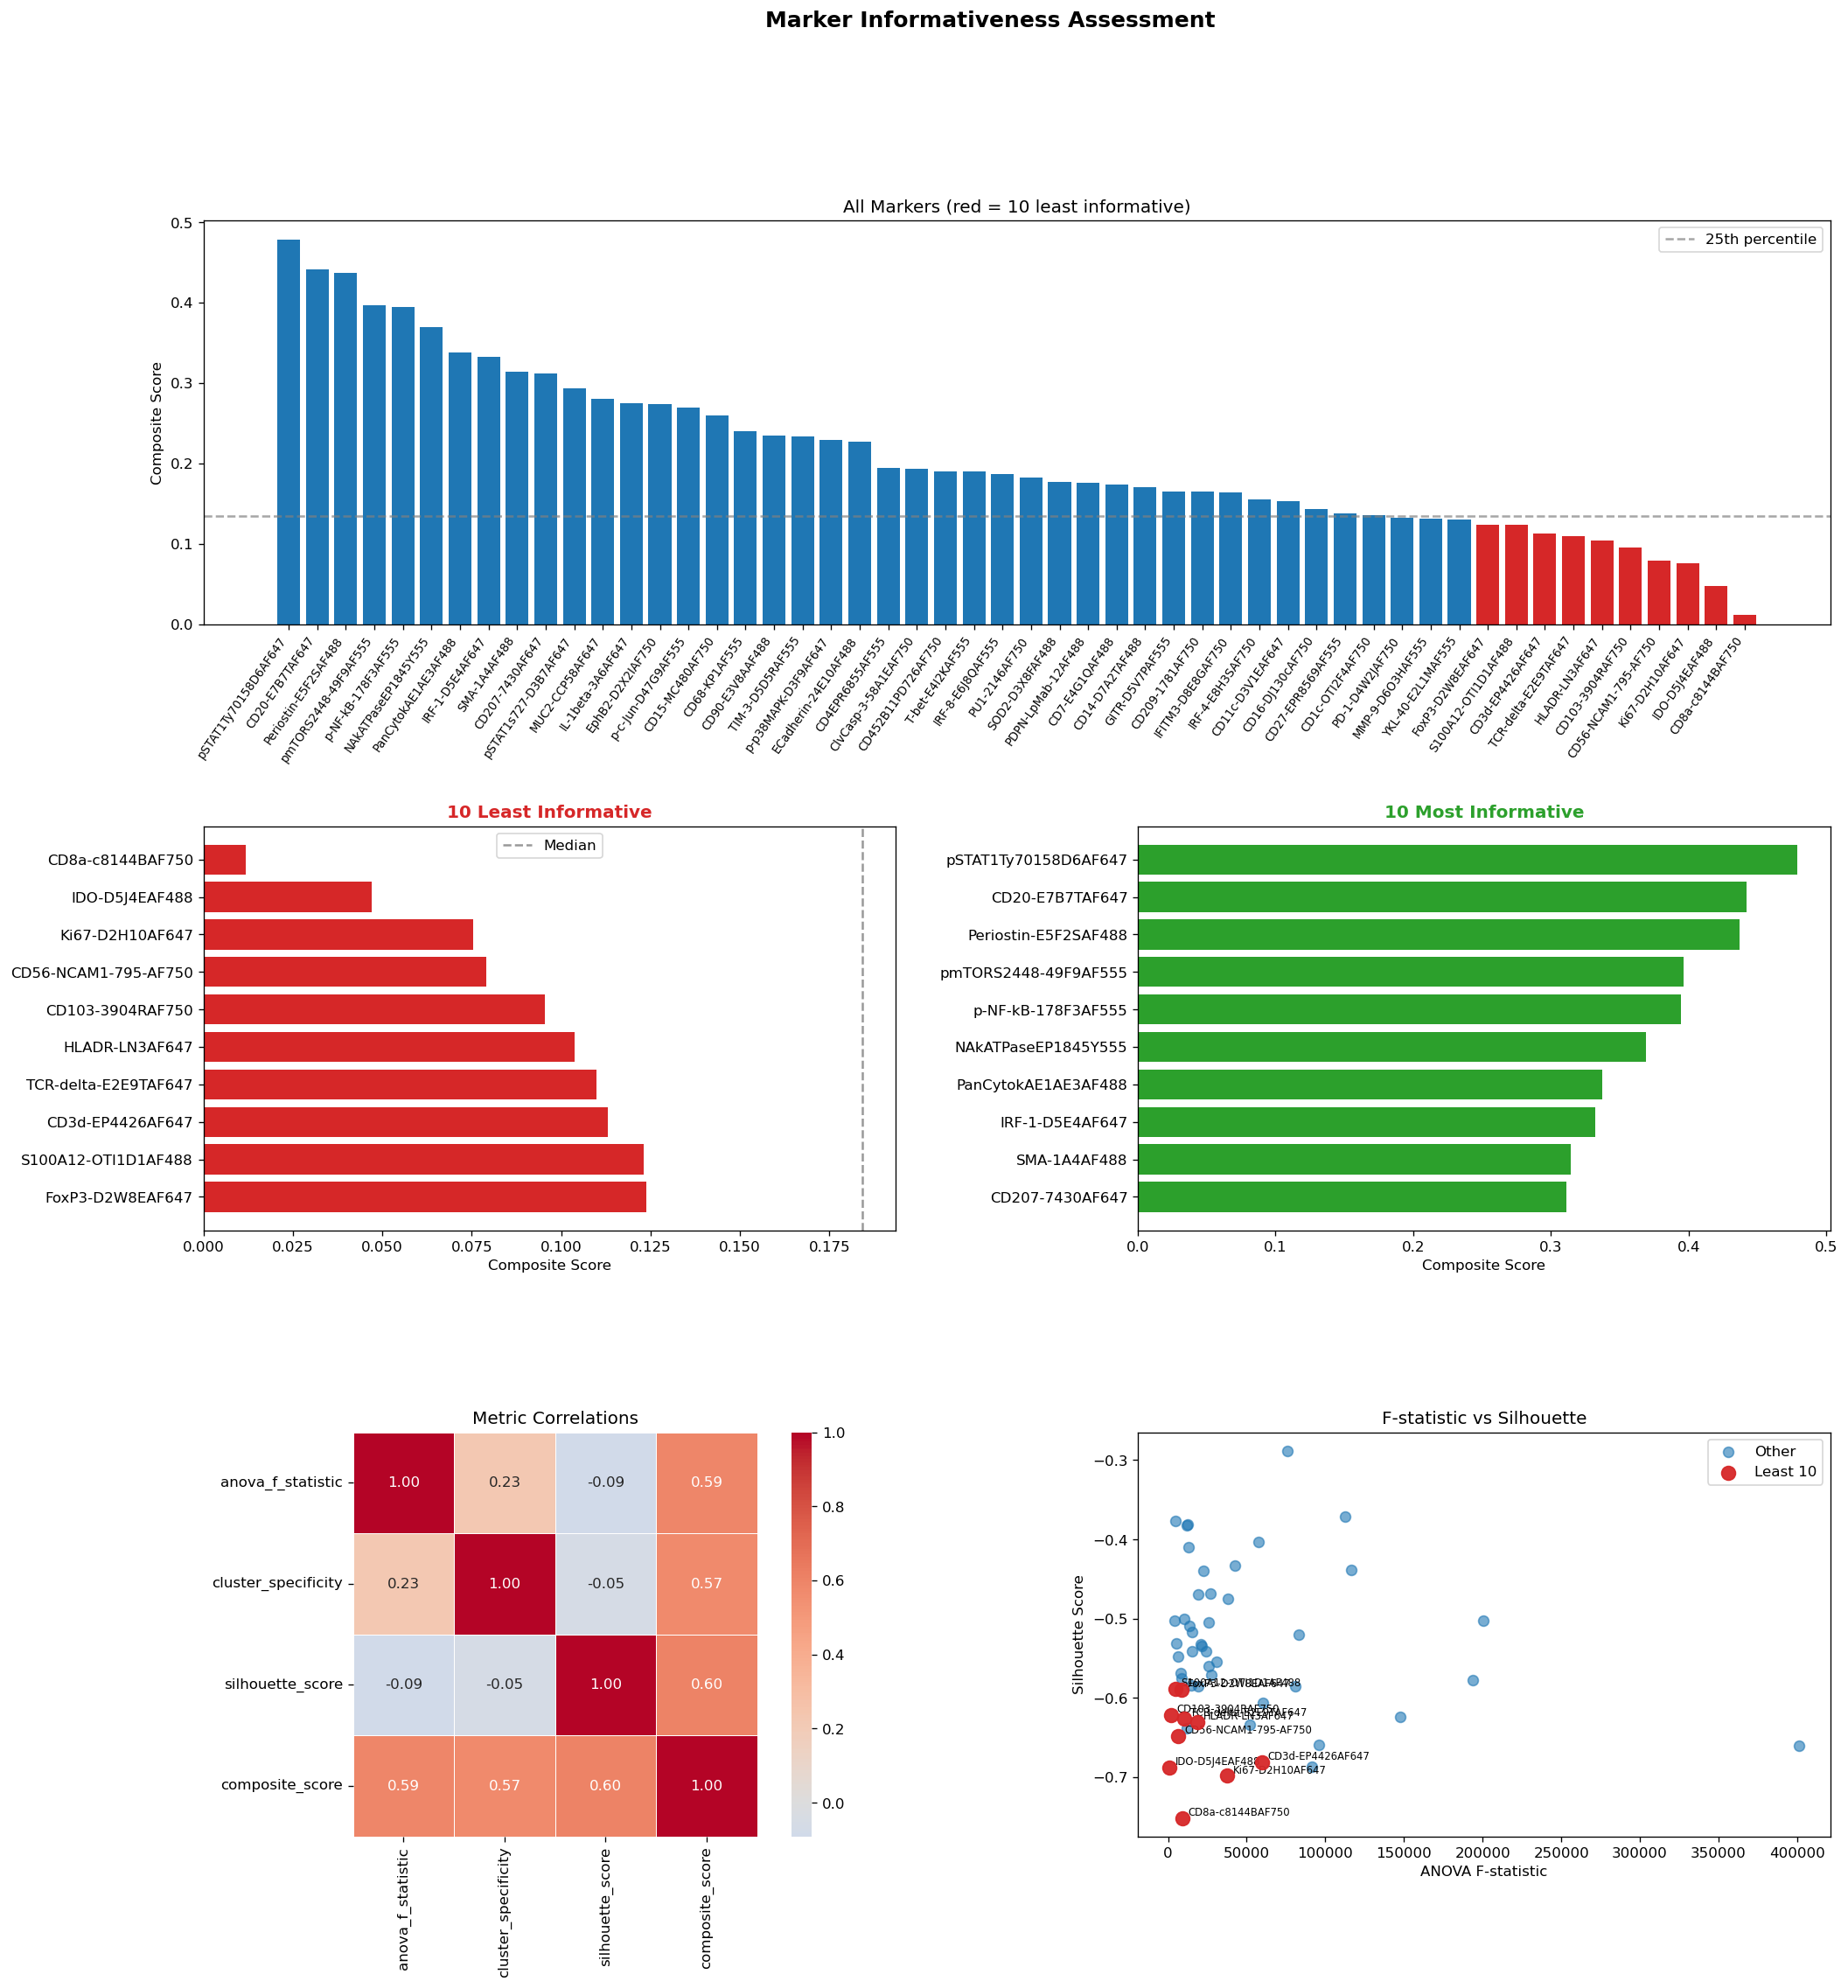

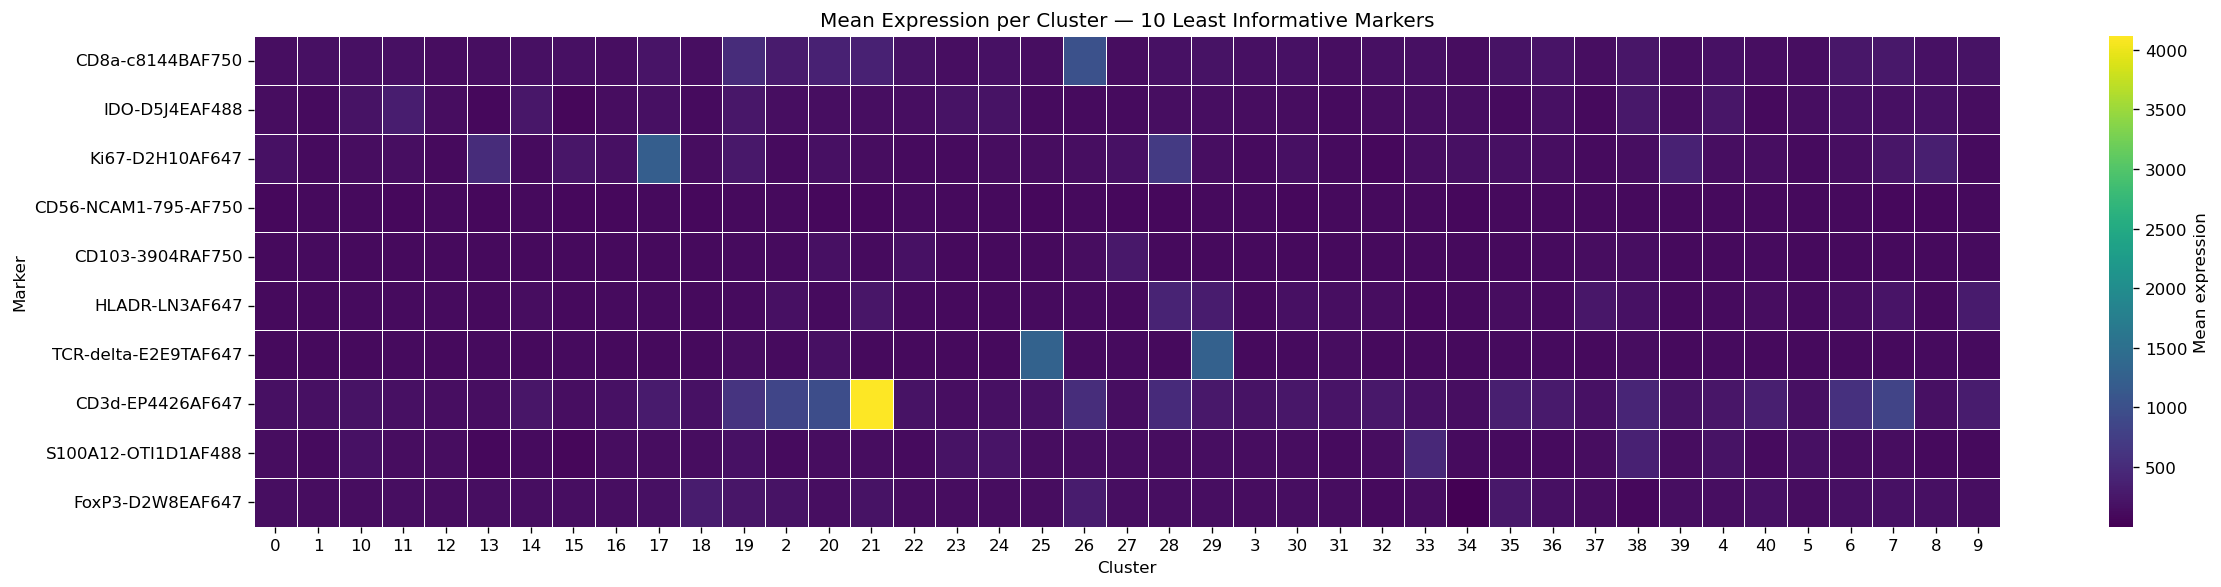

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# ── CONFIG ────────────────────────────────────────────────────────────────────
LAYER     = 'normalized'   # change to 'intensity_mean', 'X_mean', etc. or None for .X
SUBSAMPLE = 50_000         # cells for silhouette; set None to use all (slow on 4M+ cells)
# ─────────────────────────────────────────────────────────────────────────────

# Extract expression matrix
if LAYER and LAYER in adata.layers:
    X = adata.layers[LAYER]
else:
    X = adata.X

if hasattr(X, 'toarray'):
    X = X.toarray()
else:
    X = np.array(X)

markers = (list(adata.var['marker_name']) if 'marker_name' in adata.var.columns
           else list(adata.var_names))
labels  = adata.obs['leiden'].astype(str).values
unique_clusters = np.unique(labels)

print(f'{X.shape[0]:,} cells  |  {len(markers)} markers  |  {len(unique_clusters)} clusters')


# ── METRIC 1: ANOVA F-statistic ───────────────────────────────────────────────
print('Computing ANOVA F-statistics ...')
f_stats, p_vals = [], []
for j in range(X.shape[1]):
    groups = [X[labels == c, j] for c in unique_clusters]
    try:
        f, p = stats.f_oneway(*groups)
    except Exception:
        f, p = 0.0, 1.0
    f_stats.append(f if np.isfinite(f) else 0.0)
    p_vals.append( p if np.isfinite(p) else 1.0)
f_stats, p_vals = np.array(f_stats), np.array(p_vals)


# ── METRIC 2: Cluster specificity (max cluster mean / global mean) ────────────
print('Computing cluster specificity ...')
global_mean   = X.mean(axis=0) + 1e-9
cluster_means = np.vstack([X[labels == c, :].mean(axis=0) for c in unique_clusters])
specificity   = cluster_means.max(axis=0) / global_mean


# ── METRIC 3: Per-marker silhouette score ─────────────────────────────────────
n_cells = X.shape[0]
if SUBSAMPLE and n_cells > SUBSAMPLE:
    rng = np.random.default_rng(42)
    idx = rng.choice(n_cells, size=SUBSAMPLE, replace=False)
    Xs, ls = X[idx], labels[idx]
    print(f'Subsampled {SUBSAMPLE:,} / {n_cells:,} cells for silhouette ...')
else:
    Xs, ls = X, labels

print(f'Computing per-marker silhouette scores (this is the slow step) ...')
sil_scores = []
for j, m in enumerate(markers):
    col = Xs[:, j:j+1]
    if col.std() < 1e-9:
        sil_scores.append(0.0)
        continue
    try:
        s = silhouette_score(col, ls, metric='euclidean')
    except Exception:
        s = 0.0
    sil_scores.append(float(s))
    if (j + 1) % 10 == 0 or j == len(markers) - 1:
        print(f'  {j+1}/{len(markers)}')
sil_scores = np.array(sil_scores)


# ── COMPOSITE SCORE ───────────────────────────────────────────────────────────
def minmax(arr):
    r = arr.max() - arr.min()
    return (arr - arr.min()) / r if r > 0 else np.zeros_like(arr)

composite = (minmax(f_stats) + minmax(specificity) + minmax(sil_scores - sil_scores.min())) / 3.0

df_markers = pd.DataFrame({
    'marker':              markers,
    'anova_f_statistic':   np.round(f_stats,     4),
    'anova_p_value':       np.round(p_vals,      6),
    'cluster_specificity': np.round(specificity,  4),
    'silhouette_score':    np.round(sil_scores,   4),
    'composite_score':     np.round(composite,    4),
})
for i, c in enumerate(unique_clusters):
    df_markers[f'cluster_{c}_mean'] = np.round(cluster_means[i], 4)

df_markers = df_markers.sort_values('composite_score').reset_index(drop=True)
df_markers['rank_least_informative'] = df_markers.index + 1

df_markers.to_csv('marker_informativeness.csv', index=False)
print('Saved → marker_informativeness.csv')


# ── RESULTS TABLE ─────────────────────────────────────────────────────────────
cols = ['rank_least_informative', 'marker', 'anova_f_statistic',
        'cluster_specificity', 'silhouette_score', 'composite_score']

print('\n10 LEAST INFORMATIVE MARKERS')
display(df_markers[cols].head(10).style
        .background_gradient(subset=['composite_score'], cmap='Reds_r')
        .format({'anova_f_statistic': '{:.2f}', 'cluster_specificity': '{:.3f}',
                 'silhouette_score': '{:.4f}',  'composite_score': '{:.4f}'}))

print('\n10 MOST INFORMATIVE MARKERS')
display(df_markers[cols].tail(10).sort_values('composite_score', ascending=False).style
        .background_gradient(subset=['composite_score'], cmap='Greens')
        .format({'anova_f_statistic': '{:.2f}', 'cluster_specificity': '{:.3f}',
                 'silhouette_score': '{:.4f}',  'composite_score': '{:.4f}'}))


# ── PLOTS ─────────────────────────────────────────────────────────────────────
least10   = df_markers.head(10)
sorted_df = df_markers.sort_values('composite_score', ascending=False)

fig = plt.figure(figsize=(20, 20))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.35)
fig.suptitle('Marker Informativeness Assessment', fontsize=15, fontweight='bold')

# All markers bar
ax0 = fig.add_subplot(gs[0, :])
colors = ['#d62728' if m in least10['marker'].values else '#1f77b4'
          for m in sorted_df['marker']]
ax0.bar(range(len(sorted_df)), sorted_df['composite_score'], color=colors)
ax0.set_xticks(range(len(sorted_df)))
ax0.set_xticklabels(sorted_df['marker'], rotation=55, ha='right', fontsize=8)
ax0.axhline(df_markers['composite_score'].quantile(0.25), ls='--', color='gray',
            alpha=0.7, label='25th percentile')
ax0.set_ylabel('Composite Score')
ax0.set_title('All Markers (red = 10 least informative)')
ax0.legend()

# Least 10
ax1 = fig.add_subplot(gs[1, 0])
ax1.barh(least10['marker'][::-1], least10['composite_score'][::-1], color='#d62728')
ax1.axvline(df_markers['composite_score'].median(), ls='--', color='grey', alpha=0.8, label='Median')
ax1.set_title('10 Least Informative', color='#d62728', fontweight='bold')
ax1.set_xlabel('Composite Score')
ax1.legend()

# Most 10
ax2 = fig.add_subplot(gs[1, 1])
most10 = df_markers.tail(10).sort_values('composite_score', ascending=False)
ax2.barh(most10['marker'][::-1], most10['composite_score'][::-1], color='#2ca02c')
ax2.set_title('10 Most Informative', color='#2ca02c', fontweight='bold')
ax2.set_xlabel('Composite Score')

# Metric correlation heatmap
ax3 = fig.add_subplot(gs[2, 0])
sns.heatmap(df_markers[['anova_f_statistic','cluster_specificity',
                         'silhouette_score','composite_score']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax3, square=True, linewidths=0.5)
ax3.set_title('Metric Correlations')

# F-stat vs silhouette scatter
ax4 = fig.add_subplot(gs[2, 1])
hl = df_markers['marker'].isin(least10['marker'].values)
ax4.scatter(df_markers.loc[~hl, 'anova_f_statistic'], df_markers.loc[~hl, 'silhouette_score'],
            alpha=0.6, s=50, color='#1f77b4', label='Other')
ax4.scatter(df_markers.loc[hl,  'anova_f_statistic'], df_markers.loc[hl,  'silhouette_score'],
            alpha=0.95, s=90, color='#d62728', zorder=5, label='Least 10')
for _, row in df_markers[hl].iterrows():
    ax4.annotate(row['marker'], (row['anova_f_statistic'], row['silhouette_score']),
                 fontsize=7, xytext=(4, 2), textcoords='offset points')
ax4.set_xlabel('ANOVA F-statistic')
ax4.set_ylabel('Silhouette Score')
ax4.set_title('F-statistic vs Silhouette')
ax4.legend()

plt.savefig('marker_informativeness.pdf', bbox_inches='tight')
plt.show()


# Heatmap of least 10 across clusters
cluster_cols = [c for c in df_markers.columns if c.startswith('cluster_') and c.endswith('_mean')]
heat_data = (df_markers[df_markers['marker'].isin(least10['marker'].values)]
             .set_index('marker')[cluster_cols])
heat_data.columns = [c.replace('cluster_','').replace('_mean','') for c in heat_data.columns]

fig2, ax = plt.subplots(figsize=(max(16, len(unique_clusters) * 0.5), 5))
sns.heatmap(heat_data, cmap='viridis', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Mean expression'})
ax.set_title('Mean Expression per Cluster — 10 Least Informative Markers')
ax.set_xlabel('Cluster')
ax.set_ylabel('Marker')
plt.tight_layout()
plt.savefig('marker_informativeness_heatmap.pdf', bbox_inches='tight')
plt.show()

## Level 1 markers
Myeloid - CD33
T Cell - CD3
B Cell - CD19
Muscle - SMA

In [ ]:
L1 = 